<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/linnorm_dg1_surf_facilities_design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linnorm DG1 learning study: SURF and host-facility design with NeqSim

**A detailed educational follow-up: decision handoff → DG1 design basis → SURF
architecture → hydraulics and flow assurance → host process model → preliminary
equipment and utility sizing → safety and environmental screening → CAPEX, schedule,
uncertainty, assurance, and a traceable deliverables package.**

This notebook follows
[`linnorm_ncs_tie_in_opm_neqsim_master.ipynb`](../reservoir/linnorm_ncs_tie_in_opm_neqsim_master.ipynb).
The predecessor compares reservoir, host, holdback, and value scenarios. This notebook
accepts its conditional **Åsgard direct** front-runner as a hypothesis and asks:

> What SURF and host-facility definition is needed to decide whether a Linnorm tie-back is
> technically credible and worth maturing beyond an educational DG1 gate?

> **Educational and open-data limitation:** All dimensions, pressures, host margins,
> equipment capacities, weights, costs, schedules, production cases, fluid data, and risk
> rankings that are not explicitly public are labelled **ANALOGUE** or **SCENARIO**. This
> notebook contains no operator-internal or project-confidential information. It is not an
> official Equinor Capital Value Process checklist, a concept-select report, FEED package,
> design-code calculation, HAZOP, QRA, cost estimate, PDO/PIO, investment decision, or
> assurance statement. A real project can reach the opposite conclusion.


## Learning objectives

After completing the notebook, a learner should be able to:

1. distinguish a DG1 feasibility decision from concept selection, FEED, sanction, and
   detailed design;
2. convert a reservoir-to-host handoff into design cases and battery limits;
3. screen flowline diameter, pressure, phase behaviour, wall thickness, stability,
   insulation, hydrate inhibition, cooldown, riser, umbilical, and subsea architecture;
4. build a composable NeqSim host-modification process and audit mass, energy, phases,
   pressure, and product quality;
5. size the main equipment and utilities at feasibility-study fidelity;
6. create HAZID, barrier, environmental, brownfield, operability, qualification, CAPEX,
   schedule, uncertainty, and assurance registers;
7. assemble a traceable educational DG1 deliverables matrix and explain what is missing
   for a real decision.

Use the **Foundation route** for the handoff, process diagram, pipeline, NeqSim process,
and gate conclusion. Use the **Engineering route** for all sizing and assurance sections.
Use the **Project route** for deliverables, cost, schedule, risk, and decision quality.


## What “DG1” means here

Equinor publicly describes its Capital Value Process as stages separated by decision
gates. At each gate, decision-makers test expectations, realistic risk exposure, and the
quality of the decision basis. Public material does **not** expose a current,
asset-independent list of mandatory internal Equinor DG1 deliverables.

This notebook therefore uses a transparent **learning synthesis**:

- DG1 closes a feasibility phase and authorizes further concept development;
- the opportunity must appear technically feasible, economically interesting, safe to
  mature, and aligned with a credible execution path;
- alternatives, fatal flaws, uncertainties, data gaps, and work to the next gate are
  visible;
- detailed design-code compliance is planned and bounded, not claimed.

Public CVP information, Norwegian regulatory guidance, NORSOK category descriptions, DNV
pipeline guidance, PDO/PIO guidance, and AACE estimate classification inform the learning
set. Company- and project-specific governing documents always take precedence.


## Integrated calculation and assurance chain

$$\begin{aligned}
\text{predecessor handoff}
&\rightarrow \text{design cases and battery limits}\\
&\rightarrow \text{SURF hydraulics, mechanics, and flow assurance}\\
&\rightarrow \text{host process heat and material balances}\\
&\rightarrow \text{equipment, utility, weight, and layout estimates}\\
&\rightarrow \text{HSE, environment, operability, and brownfield assurance}\\
&\rightarrow \text{CAPEX, schedule, uncertainty, and DG1 recommendation}.
\end{aligned}$$

Evidence classes used throughout:

- **PUBLISHED** — copied from a linked public source;
- **DERIVED** — calculated from published or explicitly stated inputs;
- **ANALOGUE** — representative engineering value used for learning;
- **SCENARIO** — option or stress case, not a prediction;
- **REQUIRED PROJECT DATA** — missing evidence that can change the decision.


## 0. Clean Colab runtime and reproducibility

The setup cell pins NeqSim 3.16.0. The executed notebook records NeqSim, Java, Python,
platform, seed, predecessor commit, handoff hash, and export-package hash.


In [1]:
import importlib.util
import subprocess
import sys

NEQSIM_VERSION = "3.16.0"
if importlib.util.find_spec("neqsim") is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            f"neqsim=={NEQSIM_VERSION}",
        ],
        check=True,
    )
print(f"NeqSim Python package requested: {NEQSIM_VERSION}")


NeqSim Python package requested: 3.16.0


In [2]:
import hashlib
import importlib.metadata
import json
import math
import platform
import sys
import textwrap
import zipfile
from pathlib import Path

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import patches
from neqsim import jneqsim

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 150)
plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_SEED = 2731
RNG = np.random.default_rng(RANDOM_SEED)
RUN_DIRECTORY = Path.cwd() / "linnorm_dg1_run"
RUN_DIRECTORY.mkdir(exist_ok=True)

runtime = {
    "neqsim": importlib.metadata.version("neqsim"),
    "python": sys.version.split()[0],
    "java": str(jpype.java.lang.System.getProperty("java.version")),
    "platform": platform.platform(),
    "seed": RANDOM_SEED,
}
display(pd.Series(runtime, name="validated runtime"))


neqsim                                   3.16.0
python                                  3.12.13
java                                    17.0.19
platform    Linux-6.12.13-x86_64-with-glibc2.39
seed                                       2731
Name: validated runtime, dtype: object

## 1. Controlled handoff from the predecessor

The predecessor saved its result with NeqSim Java master commit
`ab314d6a0fceafe2f5f2a60213a70b7db3d7fccf` and was merged into NeqSim-Colab
master at `9d9723b53f6386d4cbca261f87baa70eaf6ab4ef`. Its conditional front-runner was
**Åsgard direct**, about 73.8 km straight-line distance, a 20-inch wet-gas screening line,
and a 2+1 producer strategy.

A follow-up accepts a compact, versioned interface rather than silently copying the whole
reservoir model. A real project would load an approved handoff from its data system.


In [3]:
PREDECESSOR_HANDOFF = {
    "repository_commit": (
        "9d9723b53f6386d4cbca261f87baa70eaf6ab4ef"
    ),
    "neqsim_java_commit": (
        "ab314d6a0fceafe2f5f2a60213a70b7db3d7fccf"
    ),
    "notebook": (
        "notebooks/reservoir/"
        "linnorm_ncs_tie_in_opm_neqsim_master.ipynb"
    ),
    "screening_concept": "ASGARD_DIRECT",
    "host": "ÅSGARD B",
    "straight_line_km": 73.82,
    "screening_route_factor": 1.15,
    "screening_nominal_diameter_in": 20.0,
    "producer_strategy": "2 online + 1 support/spare",
    "base_rate_MSm3d": 6.3,
    "low_rate_MSm3d": 3.6,
    "high_rate_MSm3d": 8.4,
    "reservoir_pressure_bara": 850.0,
    "reservoir_temperature_C": 184.0,
}
handoff_text = json.dumps(
    PREDECESSOR_HANDOFF,
    sort_keys=True,
    separators=(",", ":"),
)
HANDOFF_SHA256 = hashlib.sha256(handoff_text.encode()).hexdigest()
display(pd.Series(PREDECESSOR_HANDOFF, name="controlled handoff"))
print("Handoff SHA-256:", HANDOFF_SHA256)


Handoff SHA-256: c27a49fa77a33da5ce0b4c8a89614109a95c87d6923226d2b6c95aedaf4a4690


repository_commit                         9d9723b53f6386d4cbca261f87baa70eaf6ab4ef
neqsim_java_commit                        ab314d6a0fceafe2f5f2a60213a70b7db3d7fccf
notebook                         notebooks/reservoir/linnorm_ncs_tie_in_opm_neq...
screening_concept                                                    ASGARD_DIRECT
host                                                                      ÅSGARD B
straight_line_km                                                             73.82
screening_route_factor                                                        1.15
screening_nominal_diameter_in                                                 20.0
producer_strategy                                       2 online + 1 support/spare
base_rate_MSm3d                                                                6.3
low_rate_MSm3d                                                                 3.6
high_rate_MSm3d                                                                8.4
rese

### Design cases and battery limits

Pressure is absolute; gas flow is standard volume at 15 °C and 1.01325 bara. Actual
volume is:

$$\dot V=\dot V_s\frac{Z}{Z_s}\frac{T}{T_s}\frac{p_s}{p}$$

where $\dot V_s$ is standard flow, $Z$ is compressibility factor, $T$ is absolute
temperature, and $p$ is absolute pressure.


In [4]:
DESIGN_BASIS = {
    "engineered_route_km": (
        PREDECESSOR_HANDOFF["straight_line_km"]
        * PREDECESSOR_HANDOFF["screening_route_factor"]
    ),
    "water_depth_m": 270.0,
    "seabed_temperature_C": 4.0,
    "flowline_inlet_pressure_bara": 210.0,
    "flowline_inlet_temperature_C": 70.0,
    "minimum_arrival_pressure_bara": 80.0,
    "host_receiving_pressure_bara": 95.0,
    "host_export_pressure_bara": 150.0,
    "pipeline_design_pressure_bara": 250.0,
    "design_life_year": 25.0,
    "condensate_gas_ratio_Sm3_per_MSm3": 13.3,
    "produced_water_m3d": 150.0,
    "design_availability": 0.90,
    "evidence_class": "ANALOGUE unless linked otherwise",
}
design_cases = pd.DataFrame(
    [
        ("LOW", 3.6, "turndown, cooldown, liquid transport", "SCENARIO"),
        ("BASE", 6.3, "reference heat/material balance", "ANALOGUE"),
        ("HIGH", 8.4, "equipment and hydraulic design load", "SCENARIO"),
    ],
    columns=["case", "gas_rate_MSm3d", "purpose", "class"],
)
display(pd.Series(DESIGN_BASIS, name="DG1 design basis"))
display(design_cases)


engineered_route_km                                            84.893
water_depth_m                                                   270.0
seabed_temperature_C                                              4.0
flowline_inlet_pressure_bara                                    210.0
flowline_inlet_temperature_C                                     70.0
minimum_arrival_pressure_bara                                    80.0
host_receiving_pressure_bara                                     95.0
host_export_pressure_bara                                       150.0
pipeline_design_pressure_bara                                   250.0
design_life_year                                                 25.0
condensate_gas_ratio_Sm3_per_MSm3                                13.3
produced_water_m3d                                              150.0
design_availability                                               0.9
evidence_class                       ANALOGUE unless linked otherwise
Name: DG1 design bas

,case,gas_rate_MSm3d,purpose,class
0,LOW,3.6,"turndown, cooldown, liquid transport",SCENARIO
1,BASE,6.3,reference heat/material balance,ANALOGUE
2,HIGH,8.4,equipment and hydraulic design load,SCENARIO


### Public source and standards map

These sources establish context and later work topics. Listing a standard category does
not make this notebook compliant with that standard.


In [5]:
sources = pd.DataFrame(
    [
        (
            "Capital Value Process",
            "Equinor corporate governance",
            "https://www.equinor.com/about-us/corporate-governance",
            "public decision-gate principle",
        ),
        (
            "Linnorm host alternatives",
            "Equinor Linnorm announcement",
            "https://www.equinor.com/news/"
            "20231214-increasing-ownership-linnorm-discovery",
            "public host framing",
        ),
        (
            "Åsgard facilities",
            "Equinor Åsgard field page",
            "https://www.equinor.com/energy/asgard",
            "host type, water depth, process context",
        ),
        (
            "Norwegian development plan",
            "SODIR PDO/PIO guidance",
            "https://www.sodir.no/globalassets/1-sodir/regelverk/"
            "forskrifter/en/pdo-and-pio.pdf",
            "future regulatory information path",
        ),
        (
            "Risk reduction",
            "Havtil Framework Regulations section 11",
            "https://www.havtil.no/en/regulations/all-acts/"
            "the-framework-regulations3/II/11/",
            "risk-reduction principle",
        ),
        (
            "Risk analysis",
            "Havtil Management Regulations section 17",
            "https://www.havtil.no/en/regulations/all-acts/"
            "the-management-regulations3/V/17/",
            "major-accident and environmental risk",
        ),
        (
            "Process systems",
            "Standards Norway NORSOK P category",
            "https://standard.no/en/sectors/petroleum/"
            "norsok-standards/p-process",
            "process-system work scope",
        ),
        (
            "Subsea systems",
            "Standards Norway NORSOK U category",
            "https://standard.no/en/sectors/petroleum/"
            "norsok-standards/u-subsea",
            "subsea-system work scope",
        ),
        (
            "Pipeline system",
            "DNV pipeline codes",
            "https://www.dnv.com/energy/services/pipelines/"
            "pipeline-codes/",
            "F101/F105/F109/F110 verification plan",
        ),
        (
            "On-bottom stability",
            "DNV-RP-F109",
            "https://www.dnv.com/energy/standards-guidelines/"
            "dnv-rp-f109-on-bottom-stability-design-of-submarine-"
            "pipelines/",
            "later detailed stability verification",
        ),
        (
            "Estimate classification",
            "AACE 18R-97",
            "https://web.aacei.org/docs/default-source/toc/"
            "toc_18r-97.pdf",
            "scope maturity rather than fixed accuracy",
        ),
    ],
    columns=["topic", "source", "url", "use"],
)
sources["class"] = "PUBLISHED"
display(sources)


,topic,source,url,use,class
0,Capital Value Process,Equinor corporate governance,https://www.equinor.com/about-us/corporate-gov...,public decision-gate principle,PUBLISHED
1,Linnorm host alternatives,Equinor Linnorm announcement,https://www.equinor.com/news/20231214-increasi...,public host framing,PUBLISHED
2,Åsgard facilities,Equinor Åsgard field page,https://www.equinor.com/energy/asgard,"host type, water depth, process context",PUBLISHED
3,Norwegian development plan,SODIR PDO/PIO guidance,https://www.sodir.no/globalassets/1-sodir/rege...,future regulatory information path,PUBLISHED
4,Risk reduction,Havtil Framework Regulations section 11,https://www.havtil.no/en/regulations/all-acts/...,risk-reduction principle,PUBLISHED
5,Risk analysis,Havtil Management Regulations section 17,https://www.havtil.no/en/regulations/all-acts/...,major-accident and environmental risk,PUBLISHED
6,Process systems,Standards Norway NORSOK P category,https://standard.no/en/sectors/petroleum/norso...,process-system work scope,PUBLISHED
7,Subsea systems,Standards Norway NORSOK U category,https://standard.no/en/sectors/petroleum/norso...,subsea-system work scope,PUBLISHED
8,Pipeline system,DNV pipeline codes,https://www.dnv.com/energy/services/pipelines/...,F101/F105/F109/F110 verification plan,PUBLISHED
9,On-bottom stability,DNV-RP-F109,https://www.dnv.com/energy/standards-guideline...,later detailed stability verification,PUBLISHED


## 2. Reference architecture and battery limits

The hypothesis is a four-slot subsea template with three gas producers, manifold, chemical
injection, long HP wet-gas flowline, service line, power/control umbilical, floating-host
riser, pressure control, inlet separation, CO₂ removal, dehydration interface, export
compression, condensate/water handling, metering, and brownfield controls.


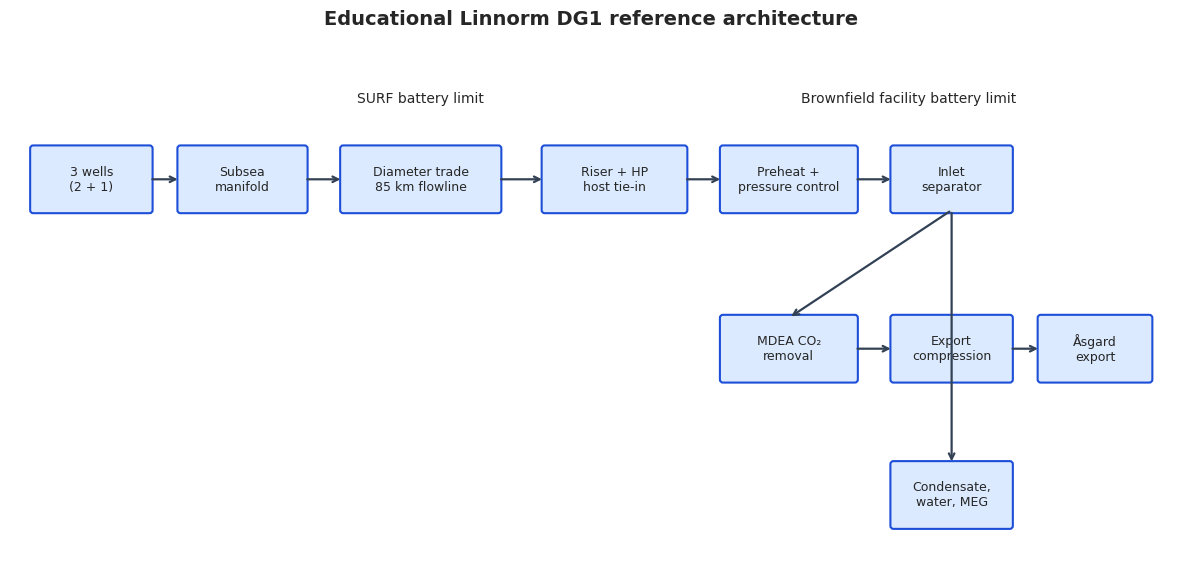

In [6]:
fig, ax = plt.subplots(figsize=(15, 7))
ax.set_xlim(0, 15)
ax.set_ylim(0, 7)
ax.axis("off")
blocks = [
    (0.3, 4.7, 1.5, 0.8, "3 wells\n(2 + 1)"),
    (2.2, 4.7, 1.6, 0.8, "Subsea\nmanifold"),
    (4.3, 4.7, 2.0, 0.8, "Diameter trade\n85 km flowline"),
    (6.9, 4.7, 1.8, 0.8, "Riser + HP\nhost tie-in"),
    (9.2, 4.7, 1.7, 0.8, "Preheat +\npressure control"),
    (11.4, 4.7, 1.5, 0.8, "Inlet\nseparator"),
    (9.2, 2.5, 1.7, 0.8, "MDEA CO₂\nremoval"),
    (11.4, 2.5, 1.5, 0.8, "Export\ncompression"),
    (13.3, 2.5, 1.4, 0.8, "Åsgard\nexport"),
    (11.4, 0.6, 1.5, 0.8, "Condensate,\nwater, MEG"),
]
for x, y, width, height, label in blocks:
    box = patches.FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.04",
        facecolor="#dbeafe",
        edgecolor="#1d4ed8",
        linewidth=1.5,
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        label,
        ha="center",
        va="center",
        fontsize=9,
    )
arrows = [
    ((1.8, 5.1), (2.2, 5.1)),
    ((3.8, 5.1), (4.3, 5.1)),
    ((6.3, 5.1), (6.9, 5.1)),
    ((8.7, 5.1), (9.2, 5.1)),
    ((10.9, 5.1), (11.4, 5.1)),
    ((12.15, 4.7), (10.05, 3.3)),
    ((10.9, 2.9), (11.4, 2.9)),
    ((12.9, 2.9), (13.3, 2.9)),
    ((12.15, 4.7), (12.15, 1.4)),
]
for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={"arrowstyle": "->", "lw": 1.6, "color": "#334155"},
    )
ax.text(5.3, 6.1, "SURF battery limit", ha="center", fontsize=10)
ax.text(
    11.6,
    6.1,
    "Brownfield facility battery limit",
    ha="center",
    fontsize=10,
)
ax.set_title(
    "Educational Linnorm DG1 reference architecture",
    fontsize=14,
    weight="bold",
)
plt.show()


A battery limit is where ownership of a design variable changes. The well team supplies
shut-in and flowing envelopes; SURF returns backpressure and chemical needs; the host
returns arrival, slug, solids, composition, and utility envelopes.

$$p_{\mathrm{tree}}\geq\Delta p_{\mathrm{SURF}}+p_{\mathrm{host,min}}+\Delta p_{\mathrm{control}}$$

Positive steady-state margin is necessary but does not prove startup, shutdown, turndown,
cooldown, restart, or terrain-slug operability.


In [7]:
interfaces = pd.DataFrame(
    [
        ("reservoir / well", "rate, THP/THT, SIWHP, water, solids",
         "SURF backpressure", "REQUIRED PROJECT DATA"),
        ("tree / flowline", "tree stream and chemical rates",
         "allowable P/T", "REQUIRED PROJECT DATA"),
        ("flowline / riser", "arrival P/T/phases/slug",
         "riser motion/fatigue", "REQUIRED PROJECT DATA"),
        ("riser / Åsgard B", "arrival stream/design pressure",
         "ESD/tie-in/shutdown", "REQUIRED PROJECT DATA"),
        ("new process / export", "treated products and loads",
         "quality/ullage/utilities", "REQUIRED PROJECT DATA"),
    ],
    columns=["interface", "supplied", "returned", "real-project status"],
)
display(interfaces)


,interface,supplied,returned,real-project status
0,reservoir / well,"rate, THP/THT, SIWHP, water, solids",SURF backpressure,REQUIRED PROJECT DATA
1,tree / flowline,tree stream and chemical rates,allowable P/T,REQUIRED PROJECT DATA
2,flowline / riser,arrival P/T/phases/slug,riser motion/fatigue,REQUIRED PROJECT DATA
3,riser / Åsgard B,arrival stream/design pressure,ESD/tie-in/shutdown,REQUIRED PROJECT DATA
4,new process / export,treated products and loads,quality/ullage/utilities,REQUIRED PROJECT DATA


## 3. Fluid model and thermodynamic points

The predecessor's E300-derived dry-gas analogue is retained. Peng–Robinson with classic
mixing is used for hydrocarbon process and pipeline work; SRK-CPA is used for water, MEG,
MDEA, and hydrate screens.

$$\sum_i z_i=1$$

$$f_i^{(\alpha)}=f_i^{(\beta)}$$

The analogue is not tuned to Linnorm laboratory PVT, water, H₂S, or condensate data.


In [8]:
LINNORM_COMPOSITION = {
    "nitrogen": 0.0050,
    "CO2": 0.0750,
    "H2S": 0.000020,
    "methane": 0.8950,
    "ethane": 0.0150,
    "propane": 0.0050,
    "n-hexane": 0.0030,
    "nC10": 0.0015,
    "nC15": 0.0004,
    "nC20": 0.00008,
}
LINNORM_COMPOSITION["methane"] += 1.0 - sum(
    LINNORM_COMPOSITION.values()
)
composition_table = pd.DataFrame(
    {
        "component": LINNORM_COMPOSITION.keys(),
        "mole_fraction": LINNORM_COMPOSITION.values(),
    }
)
composition_table["mol_percent"] = (
    100.0 * composition_table["mole_fraction"]
)
composition_table["class"] = "ANALOGUE"
display(composition_table)
print("Composition sum:", composition_table["mole_fraction"].sum())


Composition sum: 0.9999999999999999


,component,mole_fraction,mol_percent,class
0,nitrogen,0.00500,0.500,ANALOGUE
1,CO2,0.07500,7.500,ANALOGUE
2,H2S,0.00002,0.002,ANALOGUE
3,methane,0.89500,89.500,ANALOGUE
4,ethane,0.01500,1.500,ANALOGUE
5,propane,0.00500,0.500,ANALOGUE
6,n-hexane,0.00300,0.300,ANALOGUE
7,nC10,0.00150,0.150,ANALOGUE
8,nC15,0.00040,0.040,ANALOGUE
9,nC20,0.00008,0.008,ANALOGUE


In [9]:
J = jpype.JClass
SystemPrEos = J("neqsim.thermo.system.SystemPrEos")
SystemSrkCPAstatoil = J(
    "neqsim.thermo.system.SystemSrkCPAstatoil"
)
ThermodynamicOperations = J(
    "neqsim.thermodynamicoperations.ThermodynamicOperations"
)
Stream = J("neqsim.process.equipment.stream.Stream")
PipeBeggsAndBrills = J(
    "neqsim.process.equipment.pipeline.PipeBeggsAndBrills"
)
Heater = J("neqsim.process.equipment.heatexchanger.Heater")
Cooler = J("neqsim.process.equipment.heatexchanger.Cooler")
Separator = J("neqsim.process.equipment.separator.Separator")
Compressor = J("neqsim.process.equipment.compressor.Compressor")
ThrottlingValve = J(
    "neqsim.process.equipment.valve.ThrottlingValve"
)
SimpleAmineAbsorber = J(
    "neqsim.process.equipment.absorber.SimpleAmineAbsorber"
)
ProcessSystem = J("neqsim.process.processmodel.ProcessSystem")

def build_linnorm_fluid(temperature_C, pressure_bara):
    fluid = SystemPrEos(
        float(temperature_C) + 273.15,
        float(pressure_bara),
    )
    for component, fraction in LINNORM_COMPOSITION.items():
        fluid.addComponent(component, float(fraction))
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid


In [10]:
thermodynamic_points = [
    ("reservoir", 184.0, 850.0),
    ("flowline inlet", 70.0, 210.0),
    ("cold arrival", 4.0, 198.0),
    ("host receiving", 40.0, 95.0),
    ("standard", 15.0, 1.01325),
]
flash_rows = []
for name, temperature_C, pressure_bara in thermodynamic_points:
    fluid = build_linnorm_fluid(temperature_C, pressure_bara)
    operations = ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.initProperties()
    gas_phase = fluid.getPhase("gas")
    flash_rows.append(
        {
            "point": name,
            "temperature_C": temperature_C,
            "pressure_bara": pressure_bara,
            "phases": int(fluid.getNumberOfPhases()),
            "gas_Z": float(gas_phase.getZ()),
            "gas_density_kg_m3": float(
                gas_phase.getDensity("kg/m3")
            ),
            "gas_viscosity_cP": float(
                gas_phase.getViscosity("cP")
            ),
        }
    )
flash_summary = pd.DataFrame(flash_rows)
STANDARD_DENSITY_KG_SM3 = float(
    flash_summary.loc[
        flash_summary["point"] == "standard",
        "gas_density_kg_m3",
    ].iloc[0]
)
display(flash_summary)


,point,temperature_C,pressure_bara,phases,gas_Z,gas_density_kg_m3,gas_viscosity_cP
0,reservoir,184.0,850.00000,1,1.384034,285.500792,0.037064
1,flowline inlet,70.0,210.00000,1,0.867167,155.323728,0.020202
2,cold arrival,4.0,198.00000,1,0.707266,218.597690,0.023279
3,host receiving,40.0,95.00000,2,0.838930,80.211495,0.014877
4,standard,15.0,1.01325,2,0.997137,0.799169,0.011351


## 4. Flowline diameter and hydraulic screen

The predecessor used 20 inch. Candidate nominal outside diameters are now tested for
low/base/high rates over 84.9 km, with 25.4 mm provisional wall and 4 °C seabed.
NeqSim `PipeBeggsAndBrills` is the primary steady-state model.

$$v=\frac{4\dot V}{\pi D_i^2}$$

Failed nonlinear pressure solutions remain failed candidates.


In [11]:
candidate_OD_in = [14.0, 16.0, 18.0, 20.0]
provisional_wall_m = 0.0254
pipeline_rows = []
pipeline_objects = {}
for nominal_OD_in in candidate_OD_in:
    inner_diameter_m = (
        nominal_OD_in * 0.0254 - 2.0 * provisional_wall_m
    )
    for case in design_cases.itertuples():
        inlet_fluid = build_linnorm_fluid(
            DESIGN_BASIS["flowline_inlet_temperature_C"],
            DESIGN_BASIS["flowline_inlet_pressure_bara"],
        )
        inlet_stream = Stream(
            f"{nominal_OD_in:.0f}-in {case.case} inlet",
            inlet_fluid,
        )
        inlet_stream.setFlowRate(
            float(case.gas_rate_MSm3d),
            "MSm3/day",
        )
        inlet_stream.run()
        pipeline = PipeBeggsAndBrills(
            f"{nominal_OD_in:.0f}-in {case.case} flowline",
            inlet_stream,
        )
        pipeline.setLength(
            DESIGN_BASIS["engineered_route_km"] * 1000.0
        )
        pipeline.setDiameter(inner_diameter_m)
        pipeline.setPipeWallRoughness(4.5e-5)
        pipeline.setElevation(0.0)
        pipeline.setNumberOfIncrements(40)
        pipeline.setConstantSurfaceTemperature(
            DESIGN_BASIS["seabed_temperature_C"],
            "C",
        )
        pipeline.setOuterHeatTransferCoefficient(8.0)
        try:
            pipeline.run()
            outlet = pipeline.getOutletStream()
            area_m2 = math.pi * inner_diameter_m**2 / 4.0
            actual_flow_m3s = float(outlet.getFlowRate("m3/sec"))
            pipeline_objects[
                (nominal_OD_in, case.case)
            ] = pipeline
            row = {
                "nominal_OD_in": nominal_OD_in,
                "case": case.case,
                "rate_MSm3d": case.gas_rate_MSm3d,
                "ID_m": inner_diameter_m,
                "arrival_bara": float(outlet.getPressure("bara")),
                "arrival_C": float(outlet.getTemperature("C")),
                "velocity_m_s": actual_flow_m3s / area_m2,
                "phases": int(
                    outlet.getFluid().getNumberOfPhases()
                ),
                "status": "converged",
            }
        except Exception as error:
            row = {
                "nominal_OD_in": nominal_OD_in,
                "case": case.case,
                "rate_MSm3d": case.gas_rate_MSm3d,
                "ID_m": inner_diameter_m,
                "arrival_bara": np.nan,
                "arrival_C": np.nan,
                "velocity_m_s": np.nan,
                "phases": -1,
                "status": (
                    "failed: " + str(error).splitlines()[0][:70]
                ),
            }
        pipeline_rows.append(row)
pipeline_screen = pd.DataFrame(pipeline_rows)
display(pipeline_screen)


,nominal_OD_in,case,rate_MSm3d,ID_m,arrival_bara,arrival_C,velocity_m_s,phases,status
0,14.0,LOW,3.6,0.3048,192.289302,3.931514,2.150428,1,converged
1,14.0,BASE,6.3,0.3048,139.909659,3.313303,5.007526,2,converged
2,14.0,HIGH,8.4,0.3048,NaN,NaN,NaN,-1,failed: java.lang.RuntimeException: neqsim.uti...
3,16.0,LOW,3.6,0.3556,202.139964,3.973074,1.522837,1,converged
4,16.0,BASE,6.3,0.3556,185.431703,3.896373,2.843076,1,converged
5,16.0,HIGH,8.4,0.3556,160.905154,3.645598,4.282247,2,converged
6,18.0,LOW,3.6,0.4064,206.072873,3.987168,1.150047,1,converged
7,18.0,BASE,6.3,0.4064,197.944182,3.956533,2.071665,1,converged
8,18.0,HIGH,8.4,0.4064,188.285464,3.911682,2.868096,1,converged
9,20.0,LOW,3.6,0.4572,207.861326,3.986323,0.903144,1,converged


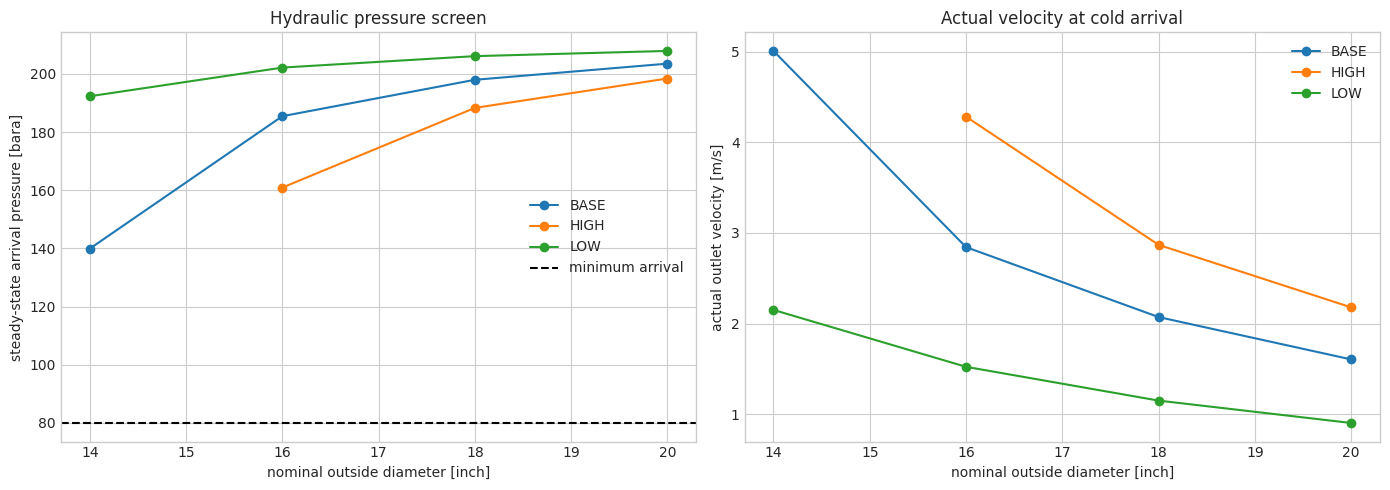

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for case_name, subset in pipeline_screen.groupby("case"):
    subset = subset.sort_values("nominal_OD_in")
    axes[0].plot(
        subset["nominal_OD_in"],
        subset["arrival_bara"],
        marker="o",
        label=case_name,
    )
    axes[1].plot(
        subset["nominal_OD_in"],
        subset["velocity_m_s"],
        marker="o",
        label=case_name,
    )
axes[0].axhline(
    DESIGN_BASIS["minimum_arrival_pressure_bara"],
    color="black",
    linestyle="--",
    label="minimum arrival",
)
axes[0].set_xlabel("nominal outside diameter [inch]")
axes[0].set_ylabel("steady-state arrival pressure [bara]")
axes[0].set_title("Hydraulic pressure screen")
axes[1].set_xlabel("nominal outside diameter [inch]")
axes[1].set_ylabel("actual outlet velocity [m/s]")
axes[1].set_title("Actual velocity at cold arrival")
for axis in axes:
    axis.legend()
fig.tight_layout()
plt.show()


In [13]:
diameter_checks = []
for nominal_OD_in, subset in pipeline_screen.groupby(
    "nominal_OD_in"
):
    converged = bool((subset["status"] == "converged").all())
    pressure_pass = bool(
        (
            subset["arrival_bara"]
            >= DESIGN_BASIS["minimum_arrival_pressure_bara"]
        ).all()
    )
    phase_pass = bool((subset["phases"] == 1).all())
    velocity_pass = bool(
        subset["velocity_m_s"].between(0.8, 18.0).all()
    )
    diameter_checks.append(
        {
            "nominal_OD_in": nominal_OD_in,
            "all_cases_converged": converged,
            "all_arrivals_above_minimum": pressure_pass,
            "single_phase_in_all_steady_cases": phase_pass,
            "velocity_screen_passed": velocity_pass,
            "DG1_screen_passed": (
                converged
                and pressure_pass
                and phase_pass
                and velocity_pass
            ),
        }
    )
diameter_decision = pd.DataFrame(diameter_checks)
SELECTED_OD_IN = float(
    diameter_decision.query("DG1_screen_passed")[
        "nominal_OD_in"
    ].min()
)
selected_pipeline = pipeline_screen.query(
    "nominal_OD_in == @SELECTED_OD_IN"
).copy()
display(diameter_decision)
print("Preliminary diameter:", f"{SELECTED_OD_IN:.0f} inch OD")


Preliminary diameter: 18 inch OD


,nominal_OD_in,all_cases_converged,all_arrivals_above_minimum,single_phase_in_all_steady_cases,velocity_screen_passed,DG1_screen_passed
0,14.0,False,False,False,False,False
1,16.0,True,True,False,True,False
2,18.0,True,True,True,True,True
3,20.0,True,True,True,True,True


### Diameter interpretation

The selected bore is the smallest tested candidate that converges, stays above the
arrival-pressure floor, remains single phase in all three steady cases, and passes a broad
velocity screen. It is not a code criterion. A larger bore reduces pressure loss but may
worsen low-rate liquid transport, linepack, steel, installation load, and cost. Terrain,
roughness growth, fluid uncertainty, decline, host pressure, and transient slugging must be
propagated before concept selection.


## 5. Wall thickness, collapse, stability, and materials

A simplified pressure-containment screen is:

$$t_p=\frac{p_dD_o}{2\alpha_U\alpha_F f_y-p_d}$$

$$t_{\mathrm{nom}}=\frac{t_p+t_{\mathrm{CA}}}{1-\delta_m}$$

DNV-ST-F101 pressure containment, collapse, propagation buckling, local buckling, load
interaction, fatigue, incidental/test pressure, de-rating, safety class, ovality,
fabrication route, and installation strain are **not** replaced.


In [14]:
mechanical_basis = {
    "SMYS_MPa": 450.0,
    "youngs_modulus_GPa": 207.0,
    "poisson_ratio": 0.30,
    "utilization_factor": 0.72,
    "fabrication_factor": 0.96,
    "corrosion_allowance_mm": 3.0,
    "negative_tolerance": 0.125,
    "steel_density_kg_m3": 7850.0,
    "seawater_density_kg_m3": 1025.0,
    "concrete_density_kg_m3": 3000.0,
}
outside_diameter_m = SELECTED_OD_IN * 0.0254
design_pressure_Pa = (
    DESIGN_BASIS["pipeline_design_pressure_bara"] * 1.0e5
)
yield_strength_Pa = mechanical_basis["SMYS_MPa"] * 1.0e6
denominator = (
    2.0
    * mechanical_basis["utilization_factor"]
    * mechanical_basis["fabrication_factor"]
    * yield_strength_Pa
    - design_pressure_Pa
)
pressure_thickness_m = (
    design_pressure_Pa * outside_diameter_m / denominator
)
required_nominal_m = (
    pressure_thickness_m
    + mechanical_basis["corrosion_allowance_mm"] / 1000.0
) / (1.0 - mechanical_basis["negative_tolerance"])
available_wall_mm = np.array([19.1, 22.2, 25.4, 28.6, 31.8])
SELECTED_WALL_MM = float(
    available_wall_mm[
        available_wall_mm >= required_nominal_m * 1000.0
    ][0]
)
SELECTED_ID_M = outside_diameter_m - (
    2.0 * SELECTED_WALL_MM / 1000.0
)
external_pressure_Pa = (
    mechanical_basis["seawater_density_kg_m3"]
    * 9.81
    * DESIGN_BASIS["water_depth_m"]
)
elastic_collapse_Pa = (
    2.0
    * mechanical_basis["youngs_modulus_GPa"]
    * 1.0e9
    / (1.0 - mechanical_basis["poisson_ratio"] ** 2)
    * (SELECTED_WALL_MM / 1000.0 / outside_diameter_m) ** 3
)
wall_screen = pd.Series(
    {
        "pressure-only thickness [mm]": (
            pressure_thickness_m * 1000.0
        ),
        "required nominal thickness [mm]": (
            required_nominal_m * 1000.0
        ),
        "selected nominal thickness [mm]": SELECTED_WALL_MM,
        "selected inner diameter [m]": SELECTED_ID_M,
        "external pressure [bar]": external_pressure_Pa / 1.0e5,
        "elastic-collapse screen [bar]": (
            elastic_collapse_Pa / 1.0e5
        ),
        "collapse / external pressure": (
            elastic_collapse_Pa / external_pressure_Pa
        ),
    },
    name="non-code mechanical screen",
)
display(wall_screen)


pressure-only thickness [mm]        19.143163
required nominal thickness [mm]     25.306472
selected nominal thickness [mm]     25.400000
selected inner diameter [m]          0.406400
external pressure [bar]             27.149175
elastic-collapse screen [bar]      780.084113
collapse / external pressure        28.733253
Name: non-code mechanical screen, dtype: float64

A Morison-style drag and Coulomb soil screen illustrates coating sensitivity:

$$F_H=\frac{1}{2}\rho_wC_DD_cU^2$$

$$R=\mu W_{\mathrm{sub}}$$

A detailed DNV-RP-F109 study requires directional waves/currents, embedment, breakout,
cyclic soil response, seabed profile, spans, and allowable displacement.


In [15]:
coating_rows = []
steel_area_m2 = math.pi / 4.0 * (
    outside_diameter_m**2 - SELECTED_ID_M**2
)
steel_mass_kg_m = (
    steel_area_m2 * mechanical_basis["steel_density_kg_m3"]
)
for coating_mm in np.arange(0.0, 101.0, 10.0):
    coated_diameter_m = (
        outside_diameter_m + 2.0 * coating_mm / 1000.0
    )
    concrete_area_m2 = math.pi / 4.0 * (
        coated_diameter_m**2 - outside_diameter_m**2
    )
    concrete_mass_kg_m = (
        concrete_area_m2
        * mechanical_basis["concrete_density_kg_m3"]
    )
    displaced_mass_kg_m = (
        math.pi
        / 4.0
        * coated_diameter_m**2
        * mechanical_basis["seawater_density_kg_m3"]
    )
    submerged_weight_N_m = (
        steel_mass_kg_m
        + concrete_mass_kg_m
        - displaced_mass_kg_m
    ) * 9.81
    drag_N_m = (
        0.5
        * mechanical_basis["seawater_density_kg_m3"]
        * 1.0
        * coated_diameter_m
        * 2.0**2
        * 1.30
    )
    resistance_N_m = 0.60 * submerged_weight_N_m
    coating_rows.append(
        {
            "concrete_coating_mm": coating_mm,
            "coated_OD_m": coated_diameter_m,
            "submerged_weight_N_m": submerged_weight_N_m,
            "design_drag_N_m": drag_N_m,
            "stability_ratio": resistance_N_m / drag_N_m,
        }
    )
stability_screen = pd.DataFrame(coating_rows)
SELECTED_COATING_MM = float(
    stability_screen.query("stability_ratio >= 1.0")[
        "concrete_coating_mm"
    ].min()
)
display(stability_screen)
print("First passing simplified coating:", SELECTED_COATING_MM, "mm")


First passing simplified coating: 50.0 mm


,concrete_coating_mm,coated_OD_m,submerged_weight_N_m,design_drag_N_m,stability_ratio
0,0.0,0.4572,1002.610435,1218.438,0.493719
1,10.0,0.4772,1286.983732,1271.738,0.607193
2,20.0,0.4972,1583.530544,1325.038,0.717050
3,30.0,0.5172,1892.250871,1378.338,0.823710
4,40.0,0.5372,2213.144712,1431.638,0.927530
5,50.0,0.5572,2546.212067,1484.938,1.028816
6,60.0,0.5772,2891.452937,1538.238,1.127831
7,70.0,0.5972,3248.867321,1591.538,1.224803
8,80.0,0.6172,3618.455220,1644.838,1.319931
9,90.0,0.6372,4000.216634,1698.138,1.413389


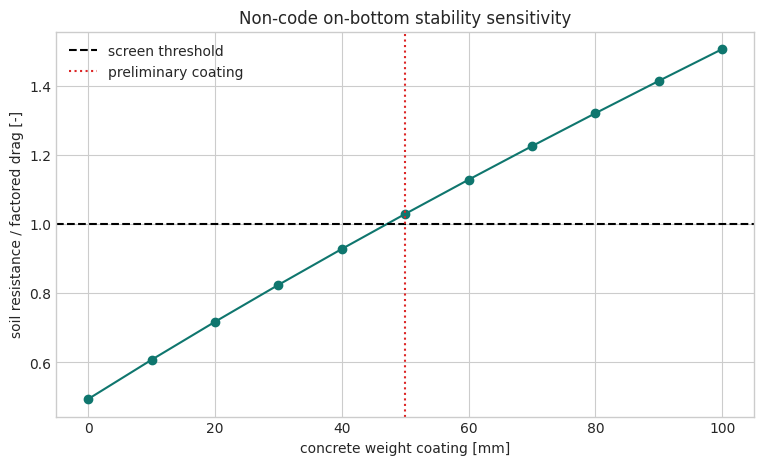

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    stability_screen["concrete_coating_mm"],
    stability_screen["stability_ratio"],
    marker="o",
    color="#0f766e",
)
ax.axhline(1.0, color="black", linestyle="--", label="screen threshold")
ax.axvline(
    SELECTED_COATING_MM,
    color="#dc2626",
    linestyle=":",
    label="preliminary coating",
)
ax.set_xlabel("concrete weight coating [mm]")
ax.set_ylabel("soil resistance / factored drag [-]")
ax.set_title("Non-code on-bottom stability sensitivity")
ax.legend()
plt.show()


The analogue has 7.5 mol% CO₂, 20 ppm H₂S, possible free water, and unknown water
chemistry. Final material selection needs pH, condensation, acids, solids, oxygen,
inhibitor uptime, top-of-line corrosion, weld data, upset exposure, inspection, repair,
installation, and lifecycle cost.


In [17]:
materials_options = pd.DataFrame(
    [
        (
            "carbon steel + allowance + inhibitor",
            "lowest initial material cost",
            "water chemistry/inhibitor/top-of-line",
            "retain",
        ),
        (
            "carbon steel with CRA clad/lined bore",
            "lower chemical dependency",
            "fabrication/buckle/installation/repair",
            "retain",
        ),
        (
            "CRA flowline",
            "high corrosion resistance",
            "cost/weld/collapse/availability",
            "upper-cost screen",
        ),
    ],
    columns=["option", "advantage", "critical uncertainty", "DG1 position"],
)
display(materials_options)


,option,advantage,critical uncertainty,DG1 position
0,carbon steel + allowance + inhibitor,lowest initial material cost,water chemistry/inhibitor/top-of-line,retain
1,carbon steel with CRA clad/lined bore,lower chemical dependency,fabrication/buckle/installation/repair,retain
2,CRA flowline,high corrosion resistance,cost/weld/collapse/availability,upper-cost screen


## 6. Thermal behaviour, hydrate inhibition, and cooldown

An independent steady thermal model is:

$$T(x)=T_s+(T_{\mathrm{in}}-T_s)\exp\left(-\frac{U\pi D_cx}{\dot m c_p}\right)$$

NeqSim SRK-CPA calculates hydrate equilibrium for uninhibited, 20 wt% MEG, and 40 wt% MEG
aqueous scenarios. Equilibrium does not predict kinetics, plugging, local water, salt,
inhibitor distribution, or restart.


In [18]:
def hydrate_temperature_C(meg_mass_fraction):
    fluid = SystemSrkCPAstatoil(273.15 + 10.0, 120.0)
    for component, fraction in LINNORM_COMPOSITION.items():
        fluid.addComponent(component, float(fraction))
    fluid.addComponent("water", 0.03)
    if meg_mass_fraction > 0.0:
        fluid.addComponent(
            "MEG",
            0.03
            * meg_mass_fraction
            / (1.0 - meg_mass_fraction),
        )
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    fluid.setHydrateCheck(True)
    operations = ThermodynamicOperations(fluid)
    operations.hydrateFormationTemperature()
    return float(fluid.getTemperature("C"))

hydrate_screen = pd.DataFrame(
    [
        {
            "aqueous_MEG_mass_fraction": fraction,
            "hydrate_equilibrium_C_at_120_bara": (
                hydrate_temperature_C(fraction)
            ),
        }
        for fraction in [0.0, 0.20, 0.40]
    ]
)
hydrate_screen["method"] = "NeqSim SRK-CPA equilibrium"
display(hydrate_screen)


,aqueous_MEG_mass_fraction,hydrate_equilibrium_C_at_120_bara,method
0,0.0,15.137961,NeqSim SRK-CPA equilibrium
1,0.2,-3.774875,NeqSim SRK-CPA equilibrium
2,0.4,-26.341305,NeqSim SRK-CPA equilibrium


In [19]:
thermal_U_W_m2K = 1.5
bulk_cp_J_kgK = 2500.0
coated_diameter_m = (
    outside_diameter_m + 2.0 * SELECTED_COATING_MM / 1000.0
)
route_m = DESIGN_BASIS["engineered_route_km"] * 1000.0
distances_m = np.linspace(0.0, route_m, 120)
thermal_rows = []
thermal_profiles = {}
for case in design_cases.itertuples():
    mass_flow_kg_s = (
        case.gas_rate_MSm3d
        * 1.0e6
        * STANDARD_DENSITY_KG_SM3
        / 86400.0
    )
    exponent = (
        thermal_U_W_m2K
        * math.pi
        * coated_diameter_m
        * distances_m
        / (mass_flow_kg_s * bulk_cp_J_kgK)
    )
    temperature_C = (
        DESIGN_BASIS["seabed_temperature_C"]
        + (
            DESIGN_BASIS["flowline_inlet_temperature_C"]
            - DESIGN_BASIS["seabed_temperature_C"]
        )
        * np.exp(-exponent)
    )
    thermal_profiles[case.case] = temperature_C
    thermal_rows.append(
        {
            "case": case.case,
            "mass_flow_kg_s": mass_flow_kg_s,
            "analytical_arrival_C": temperature_C[-1],
        }
    )
thermal_summary = pd.DataFrame(thermal_rows)
display(thermal_summary)


,case,mass_flow_kg_s,analytical_arrival_C
0,LOW,33.298715,8.535736
1,BASE,58.272751,18.289987
2,HIGH,77.697002,24.948834


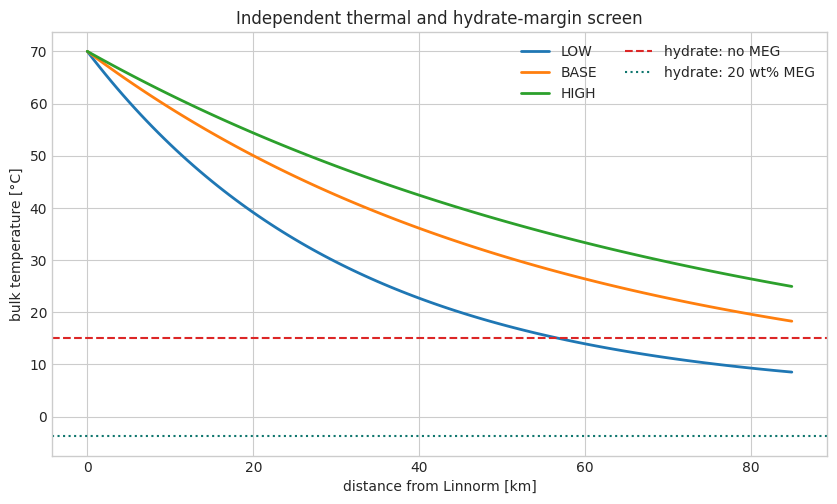

In [20]:
uninhibited_hydrate_C = float(
    hydrate_screen.loc[
        hydrate_screen["aqueous_MEG_mass_fraction"] == 0.0,
        "hydrate_equilibrium_C_at_120_bara",
    ].iloc[0]
)
meg20_hydrate_C = float(
    hydrate_screen.loc[
        hydrate_screen["aqueous_MEG_mass_fraction"] == 0.20,
        "hydrate_equilibrium_C_at_120_bara",
    ].iloc[0]
)
fig, ax = plt.subplots(figsize=(10, 5.5))
for case_name, temperatures in thermal_profiles.items():
    ax.plot(
        distances_m / 1000.0,
        temperatures,
        label=case_name,
        linewidth=2,
    )
ax.axhline(
    uninhibited_hydrate_C,
    color="#dc2626",
    linestyle="--",
    label="hydrate: no MEG",
)
ax.axhline(
    meg20_hydrate_C,
    color="#0f766e",
    linestyle=":",
    label="hydrate: 20 wt% MEG",
)
ax.set_xlabel("distance from Linnorm [km]")
ax.set_ylabel("bulk temperature [°C]")
ax.set_title("Independent thermal and hydrate-margin screen")
ax.legend(ncol=2)
plt.show()


A lumped cooldown model illustrates shutdown time:

$$T(t)=T_s+(T_0-T_s)\exp\left(-\frac{UA}{C_{\mathrm{line}}}t\right)$$

It omits axial gradients, multilayer insulation, seabed contact, phase change, liquid
holdup, pressure decline, and water distribution.


In [21]:
pipe_internal_area_m2 = math.pi * SELECTED_ID_M**2 / 4.0
concrete_area_m2 = math.pi / 4.0 * (
    coated_diameter_m**2 - outside_diameter_m**2
)
heat_capacity_J_mK = (
    steel_mass_kg_m * 500.0
    + concrete_area_m2
    * mechanical_basis["concrete_density_kg_m3"]
    * 900.0
    + pipe_internal_area_m2 * 150.0 * 2500.0
)
conductance_W_mK = (
    thermal_U_W_m2K * math.pi * coated_diameter_m
)
cooldown_tau_h = (
    heat_capacity_J_mK / conductance_W_mK / 3600.0
)
ratio = (
    (uninhibited_hydrate_C - DESIGN_BASIS["seabed_temperature_C"])
    / (
        DESIGN_BASIS["flowline_inlet_temperature_C"]
        - DESIGN_BASIS["seabed_temperature_C"]
    )
)
time_to_hydrate_h = -cooldown_tau_h * math.log(ratio)
cooldown_screen = pd.Series(
    {
        "thermal time constant [h]": cooldown_tau_h,
        "time to uninhibited equilibrium [h]": time_to_hydrate_h,
        "20 wt% MEG equilibrium [C]": meg20_hydrate_C,
        "seabed temperature [C]": (
            DESIGN_BASIS["seabed_temperature_C"]
        ),
        "shutdown strategy": (
            "maintain MEG, isolate, depressurize or displace"
        ),
    },
    name="lumped educational cooldown screen",
)
display(cooldown_screen)


thermal time constant [h]                                                    42.209773
time to uninhibited equilibrium [h]                                          75.103662
20 wt% MEG equilibrium [C]                                                   -3.774875
seabed temperature [C]                                                             4.0
shutdown strategy                      maintain MEG, isolate, depressurize or displace
Name: lumped educational cooldown screen, dtype: object

In [22]:
flow_assurance_register = pd.DataFrame(
    [
        (
            "hydrate at low rate",
            "MEG + insulation + minimum rate",
            "controlled depressurization",
            "AMBER",
        ),
        (
            "terrain liquid accumulation",
            "route/diameter/minimum rate",
            "controlled ramp/slug handling",
            "RED: transient model",
        ),
        (
            "corrosion with free water",
            "material/inhibitor/water control",
            "integrity response",
            "RED: water chemistry",
        ),
        (
            "restart after long shutdown",
            "inventory strategy",
            "staged restart",
            "RED: dynamic verification",
        ),
        (
            "slug overload at host",
            "surge volume/ramp control",
            "rate cutback/protection",
            "AMBER",
        ),
    ],
    columns=["hazard", "prevention", "recovery", "status"],
)
display(flow_assurance_register)


,hazard,prevention,recovery,status
0,hydrate at low rate,MEG + insulation + minimum rate,controlled depressurization,AMBER
1,terrain liquid accumulation,route/diameter/minimum rate,controlled ramp/slug handling,RED: transient model
2,corrosion with free water,material/inhibitor/water control,integrity response,RED: water chemistry
3,restart after long shutdown,inventory strategy,staged restart,RED: dynamic verification
4,slug overload at host,surge volume/ramp control,rate cutback/protection,AMBER


## 7. Subsea system, riser, umbilical, and availability

Åsgard B is publicly described as a semi-submersible gas-processing platform in 240–310 m
water depth. A flexible-riser reference is retained only for comparison; motion, fatigue,
interference, pressure/temperature cycling, end fittings, sour service, installation, and
host porch loads require project analysis.


In [23]:
subsea_scope = pd.DataFrame(
    [
        ("production wells", 3, "2 online + 1 support/spare", "ANALOGUE"),
        ("four-slot template/manifold", 1, "one spare slot", "SCENARIO"),
        ("production jumpers", 3, "retrievable interfaces", "SCENARIO"),
        (
            "wet-gas flowline",
            1,
            f"{SELECTED_OD_IN:.0f}-in, "
            f"{DESIGN_BASIS['engineered_route_km']:.1f} km",
            "DERIVED",
        ),
        ("MEG/service line", 1, "4-in learning basis", "ANALOGUE"),
        ("power/control umbilical", 1, "90 km allowance", "ANALOGUE"),
        ("flexible riser + host porch", 1, "floating host", "SCENARIO"),
        ("isolation/chemical system", 1, "local ESD", "SCENARIO"),
    ],
    columns=["system", "quantity", "reference", "class"],
)
display(subsea_scope)


,system,quantity,reference,class
0,production wells,3,2 online + 1 support/spare,ANALOGUE
1,four-slot template/manifold,1,one spare slot,SCENARIO
2,production jumpers,3,retrievable interfaces,SCENARIO
3,wet-gas flowline,1,"18-in, 84.9 km",DERIVED
4,MEG/service line,1,4-in learning basis,ANALOGUE
5,power/control umbilical,1,90 km allowance,ANALOGUE
6,flexible riser + host porch,1,floating host,SCENARIO
7,isolation/chemical system,1,local ESD,SCENARIO


### System architecture drawing

The item numbers in the drawing map directly to the scope table above. Routes are compressed
schematically: the production line is 84.9 km, while the MEG/service and umbilical lengths are
learning allowances. The drawing is not a layout, installation, or interface design.


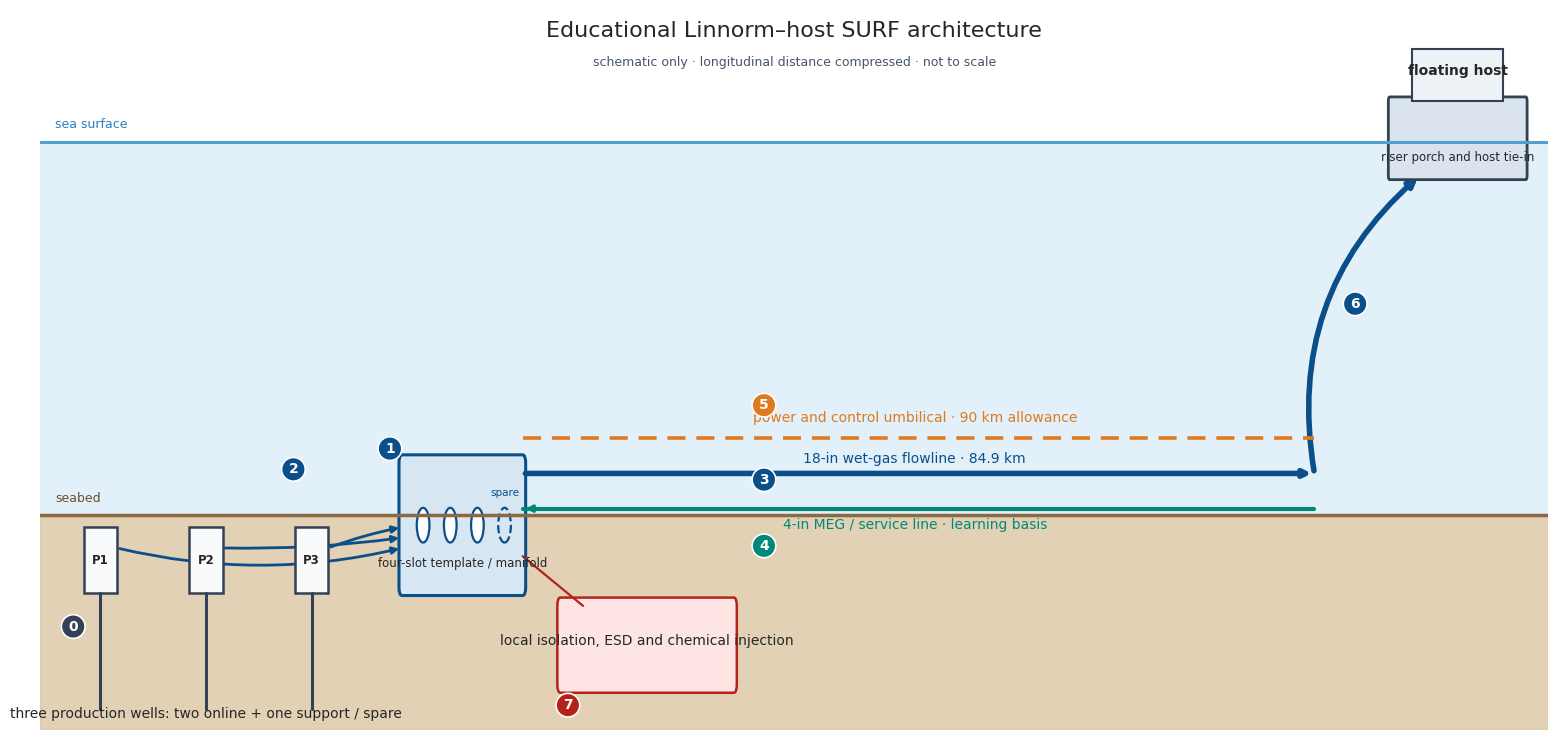

In [24]:
def add_item_badge(axis, x_value, y_value, item_number, color):
    axis.text(
        x_value,
        y_value,
        str(item_number),
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold",
        zorder=10,
        bbox={
            "boxstyle": "circle,pad=0.35",
            "facecolor": color,
            "edgecolor": "white",
            "linewidth": 1.2,
        },
    )


production_color = "#0b4f8a"
meg_color = "#00897b"
control_color = "#e07a1f"
safety_color = "#b42318"
structure_color = "#334155"
fig, ax = plt.subplots(figsize=(16, 7.5))
ax.set_xlim(0, 100)
ax.set_ylim(-5.2, 12.2)
ax.axis("off")
ax.set_facecolor("#f7fbff")
ax.axhspan(0, 9, color="#dceef8", alpha=0.85, zorder=0)
ax.axhspan(-5.2, 0, color="#d9c29c", alpha=0.75, zorder=0)
ax.plot([0, 100], [9, 9], color="#4f9fcf", linewidth=2.2)
ax.plot([0, 100], [0, 0], color="#8a6a43", linewidth=2.5)
ax.text(1, 9.35, "sea surface", color="#2c7fb8", fontsize=9)
ax.text(1, 0.3, "seabed", color="#6b4f2f", fontsize=9)

well_x_positions = [4.0, 11.0, 18.0]
for well_index, well_x in enumerate(well_x_positions):
    tree = patches.Rectangle(
        (well_x - 1.1, -1.9),
        2.2,
        1.6,
        facecolor="#f8fafc",
        edgecolor=structure_color,
        linewidth=1.8,
    )
    ax.add_patch(tree)
    ax.plot(
        [well_x, well_x],
        [-1.9, -4.7],
        color=structure_color,
        linewidth=2.2,
    )
    ax.text(
        well_x,
        -1.1,
        f"P{well_index + 1}",
        ha="center",
        va="center",
        fontsize=8.5,
        fontweight="bold",
    )
    jumper = patches.FancyArrowPatch(
        (well_x + 1.1, -0.8),
        (24.0, -0.8 + 0.25 * well_index),
        connectionstyle=f"arc3,rad={0.12 - 0.08 * well_index}",
        arrowstyle="-|>",
        mutation_scale=10,
        linewidth=2.0,
        color=production_color,
    )
    ax.add_patch(jumper)

manifold = patches.FancyBboxPatch(
    (24, -1.75),
    8,
    3.0,
    boxstyle="round,pad=0.2",
    facecolor="#d7e6f3",
    edgecolor=production_color,
    linewidth=2.2,
)
ax.add_patch(manifold)
for slot_index, slot_x in enumerate([25.4, 27.2, 29.0, 30.8]):
    slot_fill = "white" if slot_index < 3 else "none"
    slot_style = "-" if slot_index < 3 else "--"
    slot = patches.Circle(
        (slot_x, -0.25),
        0.42,
        facecolor=slot_fill,
        edgecolor=production_color,
        linestyle=slot_style,
        linewidth=1.6,
    )
    ax.add_patch(slot)
ax.text(28, -1.25, "four-slot template / manifold", ha="center", fontsize=8.5)
ax.text(30.8, 0.45, "spare", ha="center", fontsize=7.5, color=production_color)

isolation_box = patches.FancyBboxPatch(
    (34.5, -4.1),
    11.5,
    1.9,
    boxstyle="round,pad=0.2",
    facecolor="#fee4e2",
    edgecolor=safety_color,
    linewidth=1.8,
)
ax.add_patch(isolation_box)
ax.plot([32, 36], [-1.0, -2.2], color=safety_color, linewidth=1.6)
ax.text(40.25, -3.15, "local isolation, ESD and chemical injection", ha="center")

route_start_x = 32.0
route_end_x = 84.5
ax.annotate(
    "",
    xy=(route_end_x, 1.0),
    xytext=(route_start_x, 1.0),
    arrowprops={"arrowstyle": "-|>", "color": production_color, "lw": 4.0},
)
ax.plot(
    [route_start_x, route_end_x],
    [0.15, 0.15],
    color=meg_color,
    linewidth=3.0,
)
ax.annotate(
    "",
    xy=(route_start_x, 0.15),
    xytext=(route_end_x, 0.15),
    arrowprops={"arrowstyle": "-|>", "color": meg_color, "lw": 2.2},
)
ax.plot(
    [route_start_x, route_end_x],
    [1.85, 1.85],
    color=control_color,
    linewidth=2.6,
    linestyle=(0, (5, 3)),
)
ax.text(58, 1.25, "18-in wet-gas flowline · 84.9 km", ha="center", color=production_color)
ax.text(58, -0.35, "4-in MEG / service line · learning basis", ha="center", color=meg_color)
ax.text(
    58,
    2.25,
    "power and control umbilical · 90 km allowance",
    ha="center",
    color=control_color,
)

riser = patches.FancyArrowPatch(
    (84.5, 1.0),
    (91.5, 8.2),
    connectionstyle="arc3,rad=-0.28",
    arrowstyle="-|>",
    mutation_scale=12,
    linewidth=4.0,
    color=production_color,
)
ax.add_patch(riser)
host_hull = patches.FancyBboxPatch(
    (89.5, 8.2),
    9.0,
    1.8,
    boxstyle="round,pad=0.1",
    facecolor="#dbe4ee",
    edgecolor=structure_color,
    linewidth=2.0,
)
ax.add_patch(host_hull)
ax.add_patch(
    patches.Rectangle(
        (91.0, 10.0),
        6.0,
        1.25,
        facecolor="#edf2f7",
        edgecolor=structure_color,
        linewidth=1.5,
    )
)
ax.text(94, 10.62, "floating host", ha="center", fontweight="bold")
ax.text(94, 8.55, "riser porch and host tie-in", ha="center", fontsize=8.5)

add_item_badge(ax, 2.2, -2.7, 0, structure_color)
add_item_badge(ax, 23.2, 1.6, 1, production_color)
add_item_badge(ax, 16.8, 1.1, 2, production_color)
add_item_badge(ax, 48.0, 0.85, 3, production_color)
add_item_badge(ax, 48.0, -0.75, 4, meg_color)
add_item_badge(ax, 48.0, 2.65, 5, control_color)
add_item_badge(ax, 87.2, 5.1, 6, production_color)
add_item_badge(ax, 35.0, -4.6, 7, safety_color)
ax.text(11, -4.9, "three production wells: two online + one support / spare", ha="center")
ax.text(50, 11.55, "Educational Linnorm–host SURF architecture", ha="center", fontsize=16)
ax.text(
    50,
    10.85,
    "schematic only · longitudinal distance compressed · not to scale",
    ha="center",
    fontsize=9,
    color="#475569",
)
plt.tight_layout()
plt.show()


Umbilical power loss is screened with:

$$I=\frac{P}{\sqrt{3}V\eta\cos\phi}$$

$$P_{\mathrm{loss}}=3I^2R$$

Reactance, capacitance, harmonics, regulation, starting, converters, armor, thermal
environment, hydraulic tubes, fiber, redundancy, dynamic section, and qualification are
omitted.


In [25]:
umbilical_rows = []
for voltage_kV in [3.3, 6.6, 11.0]:
    current_A = (
        350000.0
        / (
            math.sqrt(3.0)
            * voltage_kV
            * 1000.0
            * 0.95
            * 0.90
        )
    )
    resistance_ohm = 90.0 * 0.10
    loss_kW = 3.0 * current_A**2 * resistance_ohm / 1000.0
    umbilical_rows.append(
        {
            "voltage_kV": voltage_kV,
            "current_A": current_A,
            "line_loss_kW": loss_kW,
            "loss_fraction": loss_kW / 350.0,
        }
    )
umbilical_screen = pd.DataFrame(umbilical_rows)
display(umbilical_screen)


,voltage_kV,current_A,line_loss_kW,loss_fraction
0,3.3,71.618853,138.490023,0.395686
1,6.6,35.809427,34.622506,0.098921
2,11.0,21.485656,12.464102,0.035612


Series availability illustrates integrated consequence:

$$A_{\mathrm{series}}=\prod_jA_j$$

A real RAM model needs distributions, common-cause failures, logistics, weather, spares,
vessel access, planned maintenance, host shutdowns, and rate consequence.


In [26]:
availability_basis = pd.DataFrame(
    [
        ("well system (2 of 3 capacity)", 0.985),
        ("template and subsea valves", 0.995),
        ("flowline and service line", 0.998),
        ("riser and host tie-in", 0.992),
        ("umbilical and controls", 0.985),
        ("host process and utilities", 0.930),
    ],
    columns=["subsystem", "availability"],
)
integrated_availability = float(
    availability_basis["availability"].prod()
)
display(availability_basis)
print(
    "Illustrative integrated availability:",
    f"{integrated_availability:.1%}",
)


Illustrative integrated availability: 88.9%


,subsystem,availability
0,well system (2 of 3 capacity),0.985
1,template and subsea valves,0.995
2,flowline and service line,0.998
3,riser and host tie-in,0.992
4,umbilical and controls,0.985
5,host process and utilities,0.930


## 8. NeqSim host-modification process

The default plant exposes named equipment: cold HP arrival, preheat, isenthalpic pressure
control, inlet separation, contactor heating, simplified 90% CO₂ removal with 30 wt% MDEA,
sweet-gas compression, and aftercooling. The MDEA model imposes removal efficiency; it is
not a rate-based absorber/regenerator design.


In [27]:
def build_host_process(case_name, gas_rate_MSm3d, arrival_bara):
    feed = Stream(
        f"{case_name} Linnorm arrival",
        build_linnorm_fluid(
            DESIGN_BASIS["seabed_temperature_C"],
            arrival_bara,
        ),
    )
    feed.setFlowRate(float(gas_rate_MSm3d), "MSm3/day")
    preheater = Heater(f"{case_name} arrival preheater", feed)
    preheater.setOutTemperature(30.0, "C")
    valve = ThrottlingValve(
        f"{case_name} host pressure control",
        preheater.getOutletStream(),
    )
    valve.setOutletPressure(
        DESIGN_BASIS["host_receiving_pressure_bara"],
        "bara",
    )
    separator = Separator(
        f"{case_name} inlet separator",
        valve.getOutletStream(),
    )
    gas_heater = Heater(
        f"{case_name} contactor feed heater",
        separator.getGasOutStream(),
    )
    gas_heater.setOutTemperature(40.0, "C")
    lean_fluid = SystemSrkCPAstatoil(
        273.15 + 40.0,
        DESIGN_BASIS["host_receiving_pressure_bara"],
    )
    lean_fluid.addComponent("water", 0.70)
    lean_fluid.addComponent("MDEA", 0.30)
    lean_fluid.setMixingRule(10)
    lean_amine = Stream(f"{case_name} lean MDEA", lean_fluid)
    lean_amine.setFlowRate(
        650000.0 * float(gas_rate_MSm3d) / 6.3,
        "kg/hr",
    )
    absorber = SimpleAmineAbsorber(
        f"{case_name} MDEA contactor",
        gas_heater.getOutletStream(),
    )
    absorber.setLeanAmineInStream(lean_amine)
    absorber.setCO2RemovalEfficiency(0.90)
    compressor = Compressor(
        f"{case_name} export compressor",
        absorber.getSweetGasOutStream(),
    )
    compressor.setOutletPressure(
        DESIGN_BASIS["host_export_pressure_bara"],
        "bara",
    )
    compressor.setIsentropicEfficiency(0.76)
    cooler = Cooler(
        f"{case_name} export aftercooler",
        compressor.getOutletStream(),
    )
    cooler.setOutTemperature(35.0, "C")
    process = ProcessSystem(
        f"{case_name} Linnorm host modifications"
    )
    for equipment in [
        feed,
        preheater,
        valve,
        separator,
        gas_heater,
        lean_amine,
        absorber,
        compressor,
        cooler,
    ]:
        process.add(equipment)
    process.run()
    return {
        "process": process,
        "feed": feed,
        "preheater": preheater,
        "valve": valve,
        "separator": separator,
        "gas_heater": gas_heater,
        "lean_amine": lean_amine,
        "absorber": absorber,
        "compressor": compressor,
        "cooler": cooler,
    }


In [28]:
selected_arrivals = selected_pipeline.set_index("case")[
    "arrival_bara"
]
process_cases = {}
process_rows = []
for case in design_cases.itertuples():
    bundle = build_host_process(
        case.case,
        case.gas_rate_MSm3d,
        float(selected_arrivals.loc[case.case]),
    )
    process_cases[case.case] = bundle
    separator = bundle["separator"]
    sweet_gas = bundle["absorber"].getSweetGasOutStream()
    gas_phase = sweet_gas.getFluid().getPhase(0)
    treated_CO2 = np.nan
    for index in range(gas_phase.getNumberOfComponents()):
        component = gas_phase.getComponent(index)
        if str(component.getName()) == "CO2":
            treated_CO2 = float(component.getx())
    feed_mass = float(bundle["feed"].getFlowRate("kg/hr"))
    liquid_mass = float(
        separator.getLiquidOutStream().getFlowRate("kg/hr")
    )
    sour_gas_mass = float(
        separator.getGasOutStream().getFlowRate("kg/hr")
    )
    sweet_gas_mass = float(sweet_gas.getFlowRate("kg/hr"))
    removed_mass = sour_gas_mass - sweet_gas_mass
    closure = (
        feed_mass - liquid_mass - sweet_gas_mass - removed_mass
    )
    process_rows.append(
        {
            "case": case.case,
            "rate_MSm3d": case.gas_rate_MSm3d,
            "arrival_bara": selected_arrivals.loc[case.case],
            "post_valve_C": float(
                bundle["valve"].getOutletStream().getTemperature("C")
            ),
            "separator_liquid_kg_h": liquid_mass,
            "treated_CO2_molpct": 100.0 * treated_CO2,
            "preheat_MW": float(bundle["preheater"].getDuty())
            / 1.0e6,
            "contactor_heat_MW": float(
                bundle["gas_heater"].getDuty()
            )
            / 1.0e6,
            "compressor_power_MW": float(
                bundle["compressor"].getPower("MW")
            ),
            "aftercooler_MW": abs(
                float(bundle["cooler"].getDuty())
            )
            / 1.0e6,
            "removed_mass_kg_h": removed_mass,
            "mass_closure_kg_h": closure,
        }
    )
process_results = pd.DataFrame(process_rows)
display(process_results)


,case,rate_MSm3d,arrival_bara,post_valve_C,separator_liquid_kg_h,treated_CO2_molpct,preheat_MW,contactor_heat_MW,compressor_power_MW,aftercooler_MW,removed_mass_kg_h,mass_closure_kg_h
0,LOW,3.6,206.072873,1.625787,2610.765485,0.803848,2.873182,3.507521,2.346420,4.059073,18740.881326,-8.600182e-09
1,BASE,6.3,197.944182,2.952062,4513.266485,0.803916,5.039246,5.909519,4.106425,7.104735,32802.926438,-1.859735e-08
2,HIGH,8.4,188.285464,4.667950,5922.345516,0.803998,6.728763,7.488418,5.475531,9.475301,43747.768570,-3.259629e-08


Pressure reduction creates strong Joule–Thomson cooling, so preheating, hydrate prevention,
liquid formation, separation, host pressure, and utilities are coupled. The simple absorber
removes an explicit acid-gas product but does not close a rigorous solvent loop.


In [29]:
process_profile = pd.DataFrame(
    [
        (
            "flowline arrival",
            float(selected_arrivals.loc["BASE"]),
            4.0,
            "SURF/facility battery limit",
        ),
        (
            "after preheater",
            float(selected_arrivals.loc["BASE"]),
            30.0,
            "hydrate-safe pressure reduction",
        ),
        (
            "after pressure control",
            DESIGN_BASIS["host_receiving_pressure_bara"],
            float(
                process_results.query("case == 'BASE'")[
                    "post_valve_C"
                ].iloc[0]
            ),
            "inlet separation",
        ),
        (
            "MDEA contactor",
            DESIGN_BASIS["host_receiving_pressure_bara"],
            40.0,
            "acid-gas removal",
        ),
        (
            "export aftercooler",
            DESIGN_BASIS["host_export_pressure_bara"],
            35.0,
            "host export battery limit",
        ),
    ],
    columns=["location", "pressure_bara", "temperature_C", "purpose"],
)
display(process_profile)


,location,pressure_bara,temperature_C,purpose
0,flowline arrival,197.944182,4.000000,SURF/facility battery limit
1,after preheater,197.944182,30.000000,hydrate-safe pressure reduction
2,after pressure control,95.000000,2.952062,inlet separation
3,MDEA contactor,95.000000,40.000000,acid-gas removal
4,export aftercooler,150.000000,35.000000,host export battery limit


## 9. Feasibility equipment sizing

NeqSim loads are combined with transparent algebra:

$$v_{\max}=K\sqrt{\frac{\rho_L-\rho_G}{\rho_G}}$$

$$P_{\mathrm{rated}}=P_{\mathrm{sim}}(1+m_P)$$

$$A=\frac{Q}{U\Delta T_{\mathrm{lm}}}$$


In [30]:
high_process = process_results.query("case == 'HIGH'").iloc[0]
high_bundle = process_cases["HIGH"]
separator_gas = high_bundle["separator"].getGasOutStream()
gas_density_kg_m3 = float(
    separator_gas.getFluid().getPhase("gas").getDensity("kg/m3")
)
gas_actual_m3_s = float(separator_gas.getFlowRate("m3/sec"))
maximum_gas_velocity_m_s = (
    0.09 * math.sqrt((780.0 - gas_density_kg_m3) / gas_density_kg_m3)
)
gas_area_m2 = gas_actual_m3_s / maximum_gas_velocity_m_s
gas_diameter_m = math.sqrt(4.0 * gas_area_m2 / math.pi)
separator_diameter_m = max(
    3.5,
    math.ceil(gas_diameter_m * 2.0) / 2.0,
)
separator_length_m = (
    60.0
    / 0.45
    / (math.pi * separator_diameter_m**2 / 4.0)
)
separator_length_m = math.ceil(separator_length_m / 2.0) * 2.0
compressor_rated_MW = (
    high_process["compressor_power_MW"] * 1.10
)
preheat_area_m2 = (
    high_process["preheat_MW"] * 1.0e6 / (650.0 * 35.0)
)
cooler_area_m2 = (
    high_process["aftercooler_MW"] * 1.0e6 / (800.0 * 25.0)
)
equipment_size = pd.DataFrame(
    [
        (
            "inlet separator / slug vessel",
            f"{gas_actual_m3_s:.2f} actual m3/s",
            f"{separator_diameter_m:.1f} m ID x "
            f"{separator_length_m:.0f} m T/T",
            "60 m3 slug scenario",
        ),
        (
            "export compression",
            f"{high_process['compressor_power_MW']:.1f} MW",
            f"{compressor_rated_MW:.1f} MW rated",
            "HIGH + 10% margin",
        ),
        (
            "arrival preheater",
            f"{high_process['preheat_MW']:.1f} MW",
            f"{preheat_area_m2:.0f} m2",
            "U=650, LMTD=35 K",
        ),
        (
            "export aftercooler",
            f"{high_process['aftercooler_MW']:.1f} MW",
            f"{cooler_area_m2:.0f} m2",
            "U=800, LMTD=25 K",
        ),
    ],
    columns=["equipment", "load", "preliminary size", "basis"],
)
display(equipment_size)


,equipment,load,preliminary size,basis
0,inlet separator / slug vessel,0.76 actual m3/s,3.5 m ID x 14 m T/T,60 m3 slug scenario
1,export compression,5.5 MW,6.0 MW rated,HIGH + 10% margin
2,arrival preheater,6.7 MW,296 m2,"U=650, LMTD=35 K"
3,export aftercooler,9.5 MW,474 m2,"U=800, LMTD=25 K"


A solvent material-balance screen is:

$$\dot m_{\mathrm{solution}}=\frac{\dot n_{\mathrm{CO_2}}M_{\mathrm{MDEA}}}{w_{\mathrm{MDEA}}\Delta\alpha}$$

It is not an absorber-hydraulic or regenerator-equilibrium calculation.


In [31]:
co2_removed_kg_h = float(high_process["removed_mass_kg_h"])
co2_removed_kmol_h = co2_removed_kg_h / 44.0095
required_mdea_kg_h = (
    co2_removed_kmol_h * 119.16 / 0.50
)
required_solution_kg_h = required_mdea_kg_h / 0.30
reboiler_duty_MW = (
    co2_removed_kg_h / 1000.0 * 3.6 / 3.6
)
absorber_area_m2 = gas_actual_m3_s / 0.55
absorber_diameter_m = math.sqrt(
    4.0 * absorber_area_m2 / math.pi
)
absorber_selected_m = math.ceil(absorber_diameter_m * 2.0) / 2.0
amine_screen = pd.Series(
    {
        "acid gas removed [kg/h]": co2_removed_kg_h,
        "solution circulation [kg/h]": required_solution_kg_h,
        "NeqSim imposed circulation [kg/h]": float(
            high_bundle["lean_amine"].getFlowRate("kg/hr")
        ),
        "regenerator duty [MW]": reboiler_duty_MW,
        "minimum contactor diameter [m]": absorber_diameter_m,
        "selected contactor diameter [m]": absorber_selected_m,
        "packing height [m]": 18.0,
    },
    name="MDEA feasibility screen",
)
display(amine_screen)


acid gas removed [kg/h]               43747.768570
solution circulation [kg/h]          789675.578039
NeqSim imposed circulation [kg/h]    866666.666667
regenerator duty [MW]                    43.747769
minimum contactor diameter [m]            1.329519
selected contactor diameter [m]           1.500000
packing height [m]                       18.000000
Name: MDEA feasibility screen, dtype: float64

In [32]:
high_rate_MSm3d = float(
    design_cases.query("case == 'HIGH'")["gas_rate_MSm3d"].iloc[0]
)
water_removed_kg_h = (
    high_rate_MSm3d
    * 1.0e6
    * (300.0 - 20.0)
    / 1.0e6
    / 24.0
)
teg_circulation_kg_h = 25.0 * water_removed_kg_h
free_water_kg_h = (
    DESIGN_BASIS["produced_water_m3d"] * 1000.0 / 24.0
)
meg_injection_kg_h = (
    0.20 / 0.80 * free_water_kg_h * 1.30
)
condensate_m3d = (
    high_rate_MSm3d
    * DESIGN_BASIS["condensate_gas_ratio_Sm3_per_MSm3"]
)
liquid_systems = pd.DataFrame(
    [
        (
            "TEG dehydration",
            f"{water_removed_kg_h:.0f} kg/h water",
            f"{teg_circulation_kg_h:.0f} kg/h TEG",
            "ANALOGUE; export spec required",
        ),
        (
            "MEG injection/regeneration",
            f"{free_water_kg_h:.0f} kg/h water",
            f"{meg_injection_kg_h:.0f} kg/h MEG",
            "SCENARIO; water profile required",
        ),
        (
            "condensate handling",
            f"{condensate_m3d:.0f} m3/d",
            "to host stabilization",
            "ANALOGUE; compositional forecast",
        ),
        (
            "produced-water handling",
            f"{DESIGN_BASIS['produced_water_m3d']:.0f} m3/d",
            "host treatment/disposal",
            "SCENARIO; chemistry required",
        ),
    ],
    columns=["system", "design load", "circulation", "status"],
)
display(liquid_systems)


,system,design load,circulation,status
0,TEG dehydration,98 kg/h water,2450 kg/h TEG,ANALOGUE; export spec required
1,MEG injection/regeneration,6250 kg/h water,2031 kg/h MEG,SCENARIO; water profile required
2,condensate handling,112 m3/d,to host stabilization,ANALOGUE; compositional forecast
3,produced-water handling,150 m3/d,host treatment/disposal,SCENARIO; chemistry required


## 10. Utilities, energy, and emissions

Utilities are part of concept definition:

$$P_{\mathrm{installed}}=\sum_jP_j(1+m_j)$$

Verified host margins are required for generation, switchgear, heating, cooling, flare,
drains, nitrogen, instrument air, seawater, chemicals, and living quarters.


In [33]:
utility_loads = pd.DataFrame(
    [
        ("electrical", "export compression", compressor_rated_MW, "DERIVED"),
        ("electrical", "MDEA/TEG/MEG pumps", 1.2, "ANALOGUE"),
        ("electrical", "cooling/controls/tracing", 1.0, "ANALOGUE"),
        ("heating", "arrival preheater", float(high_process["preheat_MW"]), "NEQSIM"),
        ("heating", "contactor feed heater", float(high_process["contactor_heat_MW"]), "NEQSIM"),
        ("heating", "MDEA regeneration", reboiler_duty_MW, "DERIVED"),
        ("heating", "TEG/MEG regeneration", 5.0, "ANALOGUE"),
        ("cooling", "export aftercooler", float(high_process["aftercooler_MW"]), "NEQSIM"),
        ("cooling", "amine condenser/trim", reboiler_duty_MW * 0.75, "ANALOGUE"),
    ],
    columns=["utility", "consumer", "load_MW", "class"],
)
utility_summary = (
    utility_loads.groupby("utility", as_index=False)["load_MW"]
    .sum()
    .sort_values("load_MW", ascending=False)
)
display(utility_loads)
display(utility_summary)


,utility,consumer,load_MW,class
0,electrical,export compression,6.023084,DERIVED
1,electrical,MDEA/TEG/MEG pumps,1.200000,ANALOGUE
2,electrical,cooling/controls/tracing,1.000000,ANALOGUE
3,heating,arrival preheater,6.728763,NEQSIM
4,heating,contactor feed heater,7.488418,NEQSIM
5,heating,MDEA regeneration,43.747769,DERIVED
6,heating,TEG/MEG regeneration,5.000000,ANALOGUE
7,cooling,export aftercooler,9.475301,NEQSIM
8,cooling,amine condenser/trim,32.810826,ANALOGUE


,utility,load_MW
2,heating,62.964949
0,cooling,42.286127
1,electrical,8.223084


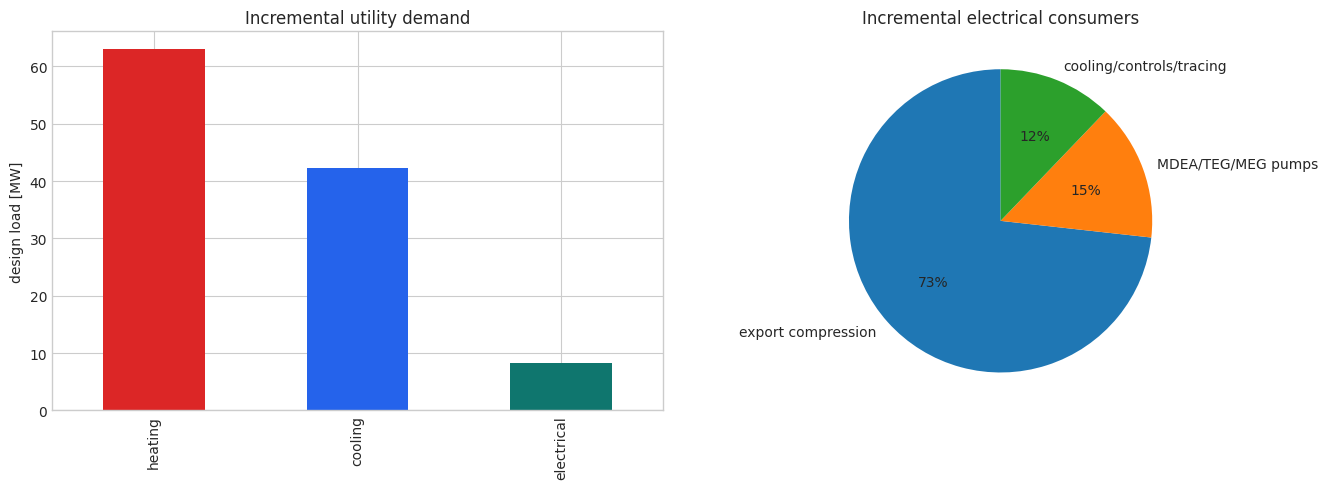

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
utility_summary.plot(
    kind="bar",
    x="utility",
    y="load_MW",
    legend=False,
    color=["#dc2626", "#2563eb", "#0f766e"],
    ax=axes[0],
)
axes[0].set_ylabel("design load [MW]")
axes[0].set_xlabel("")
axes[0].set_title("Incremental utility demand")
electrical = utility_loads.query("utility == 'electrical'")
axes[1].pie(
    electrical["load_MW"],
    labels=electrical["consumer"],
    autopct="%1.0f%%",
    startangle=90,
)
axes[1].set_title("Incremental electrical consumers")
fig.tight_layout()
plt.show()


Compression and heat-source choices strongly affect emissions:

$$E_{\mathrm{CO_2}}=P\,h_{\mathrm{operating}}\,e_P$$

Factors below are scenarios, not Åsgard measurements. A real study includes methane,
flaring, venting, fuel curves, backup generation, electricity provenance, embodied
emissions, chemicals, marine work, and regulatory reporting.


In [35]:
electrical_MW = float(
    utility_summary.query("utility == 'electrical'")["load_MW"].iloc[0]
)
heating_MW = float(
    utility_summary.query("utility == 'heating'")["load_MW"].iloc[0]
)
annual_hours = 8760.0 * DESIGN_BASIS["design_availability"]
energy_options = pd.DataFrame(
    [
        ("gas-turbine + fired heat", 0.45, 0.24, 0.00),
        ("power from shore + fired heat", 0.018, 0.24, 0.00),
        ("host power + 60% waste heat", 0.30, 0.24, 0.60),
    ],
    columns=[
        "option",
        "power_factor_t_MWh",
        "heat_factor_t_MWh",
        "heat_recovery_fraction",
    ],
)
energy_options["annual_power_GWh"] = (
    electrical_MW * annual_hours / 1000.0
)
energy_options["annual_heat_GWh"] = (
    heating_MW
    * annual_hours
    * (1.0 - energy_options["heat_recovery_fraction"])
    / 1000.0
)
energy_options["annual_CO2_kt"] = (
    electrical_MW
    * annual_hours
    * energy_options["power_factor_t_MWh"]
    + heating_MW
    * annual_hours
    * (1.0 - energy_options["heat_recovery_fraction"])
    * energy_options["heat_factor_t_MWh"]
) / 1000.0
display(energy_options)


,option,power_factor_t_MWh,heat_factor_t_MWh,heat_recovery_fraction,annual_power_GWh,annual_heat_GWh,annual_CO2_kt
0,gas-turbine + fired heat,0.450,0.24,0.0,64.830793,496.415660,148.313615
1,power from shore + fired heat,0.018,0.24,0.0,64.830793,496.415660,120.306713
2,host power + 60% waste heat,0.300,0.24,0.6,64.830793,198.566264,67.105141


## 11. Brownfield integration, weight, and layout

“Åsgard direct” does not mean “no host modification.” The model indicates pressure
control, heat, acid-gas, solvent, cooling, power, liquid, flare, and shutdown loads.
Verified host data must cover equipment curves, production forecasts, utilities,
structure, layout, fault level, switchgear, control, metering, corrosion, shutdown logic,
maintenance, and competing tie-ins.


In [36]:
brownfield_tie_ins = pd.DataFrame(
    [
        ("HP riser/porch", "hydrocarbon", "shutdown", "RED"),
        ("HP ESD and pressure control", "safeguarding", "shutdown", "RED"),
        ("inlet/slug separation", "process", "module lift", "AMBER"),
        ("MDEA treatment/regeneration", "process", "new module", "RED"),
        ("TEG/MEG systems", "chemical", "new + existing", "AMBER"),
        ("export compression", "rotating", "new/shared", "RED"),
        ("hot-medium supply/return", "utility", "shutdown", "RED"),
        ("cooling medium", "utility", "shutdown", "AMBER"),
        ("HV power and switchgear", "electrical", "shutdown", "RED"),
        ("flare/blowdown/closed drain", "safety", "shutdown", "RED"),
        ("condensate and water", "liquids", "shutdown", "AMBER"),
        ("metering and allocation", "measurement", "shutdown", "AMBER"),
        ("SAS/ESD/F&G/telecom", "control", "shutdown", "RED"),
        ("structural support/access", "layout", "offshore", "RED"),
    ],
    columns=[
        "tie_in",
        "discipline",
        "integration_mode",
        "data_status",
    ],
)
brownfield_tie_ins["class"] = "SCENARIO"
display(brownfield_tie_ins)


,tie_in,discipline,integration_mode,data_status,class
0,HP riser/porch,hydrocarbon,shutdown,RED,SCENARIO
1,HP ESD and pressure control,safeguarding,shutdown,RED,SCENARIO
2,inlet/slug separation,process,module lift,AMBER,SCENARIO
3,MDEA treatment/regeneration,process,new module,RED,SCENARIO
4,TEG/MEG systems,chemical,new + existing,AMBER,SCENARIO
5,export compression,rotating,new/shared,RED,SCENARIO
6,hot-medium supply/return,utility,shutdown,RED,SCENARIO
7,cooling medium,utility,shutdown,AMBER,SCENARIO
8,HV power and switchgear,electrical,shutdown,RED,SCENARIO
9,flare/blowdown/closed drain,safety,shutdown,RED,SCENARIO


Early layout reserves access, lifting, escape, fire/explosion separation, hazardous area,
maintenance, laydown, piping, and structural space. The plot below is not a 3D model.


In [37]:
module_items = pd.DataFrame(
    [
        ("inlet/heating", 18.0, 12.0, 650.0),
        ("MDEA contactor", 20.0, 14.0, 950.0),
        ("MDEA regeneration", 24.0, 16.0, 1250.0),
        ("compression/cooling", 22.0, 15.0, 1100.0),
        ("TEG/MEG/liquids", 18.0, 12.0, 700.0),
        ("electrical/control", 15.0, 10.0, 450.0),
    ],
    columns=["module", "length_m", "width_m", "dry_weight_t"],
)
module_items["plot_area_m2"] = (
    module_items["length_m"] * module_items["width_m"]
)
module_items["installed_weight_t"] = (
    module_items["dry_weight_t"] * 1.20
)
display(module_items)
print(
    "Installed module weight [t]:",
    f"{module_items['installed_weight_t'].sum():.0f}",
)


Installed module weight [t]: 6120


,module,length_m,width_m,dry_weight_t,plot_area_m2,installed_weight_t
0,inlet/heating,18.0,12.0,650.0,216.0,780.0
1,MDEA contactor,20.0,14.0,950.0,280.0,1140.0
2,MDEA regeneration,24.0,16.0,1250.0,384.0,1500.0
3,compression/cooling,22.0,15.0,1100.0,330.0,1320.0
4,TEG/MEG/liquids,18.0,12.0,700.0,216.0,840.0
5,electrical/control,15.0,10.0,450.0,150.0,540.0


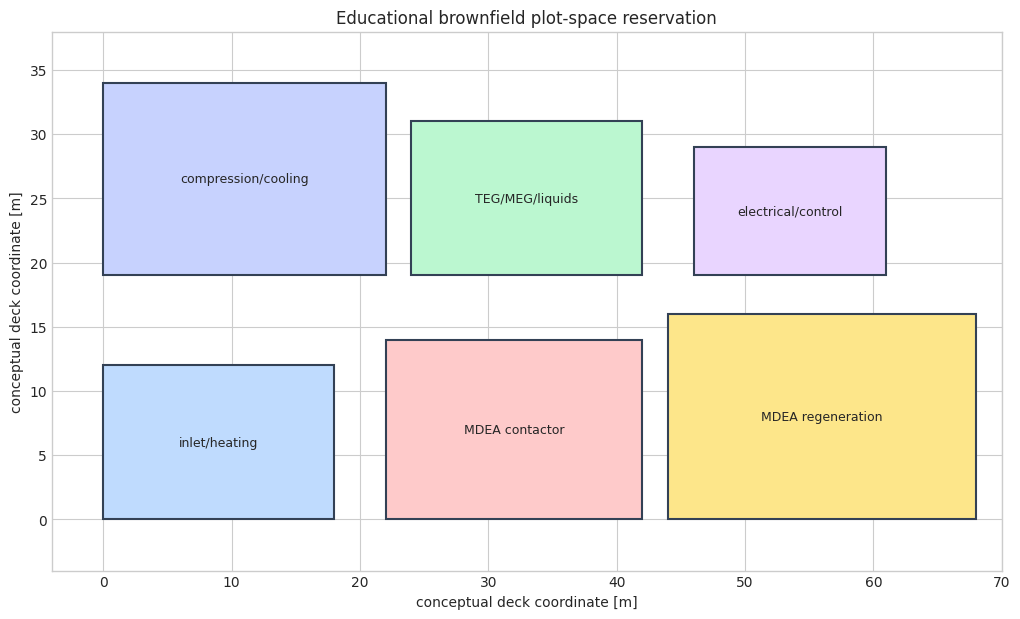

In [38]:
fig, ax = plt.subplots(figsize=(13, 7))
positions = [(0, 0), (22, 0), (44, 0), (0, 19), (24, 19), (46, 19)]
colors = ["#bfdbfe", "#fecaca", "#fde68a", "#c7d2fe", "#bbf7d0", "#e9d5ff"]
for row, position, color in zip(
    module_items.itertuples(),
    positions,
    colors,
):
    x, y = position
    rectangle = patches.Rectangle(
        (x, y),
        row.length_m,
        row.width_m,
        facecolor=color,
        edgecolor="#334155",
        linewidth=1.5,
    )
    ax.add_patch(rectangle)
    ax.text(
        x + row.length_m / 2.0,
        y + row.width_m / 2.0,
        row.module,
        ha="center",
        va="center",
        fontsize=9,
    )
ax.set_xlim(-4, 70)
ax.set_ylim(-4, 38)
ax.set_aspect("equal")
ax.set_xlabel("conceptual deck coordinate [m]")
ax.set_ylabel("conceptual deck coordinate [m]")
ax.set_title("Educational brownfield plot-space reservation")
plt.show()


## 12. Safeguarding, relief, and barrier basis

Pressure hierarchy needs confirmed SIWHP, flowline/riser/host MAWP, incidental pressure,
relief, shutdown response, and thermal expansion. A HIPPS is considered when source
pressure can exceed downstream design pressure and conventional protection cannot satisfy
risk, response, reliability, or flare constraints.

$$m=\rho V$$

$$\dot m_{\mathrm{avg}}=\frac{m_0-m_f}{t_{\mathrm{BD}}}$$

This inventory screen is not API 521/ISO 23251 sizing or transient wall-temperature work.


In [39]:
pipe_volume_m3 = (
    math.pi
    * SELECTED_ID_M**2
    / 4.0
    * DESIGN_BASIS["engineered_route_km"]
    * 1000.0
)
base_pipeline = pipeline_objects[(SELECTED_OD_IN, "BASE")]
inlet_density = float(
    base_pipeline.getInletStream().getFluid().getDensity("kg/m3")
)
outlet_density = float(
    base_pipeline.getOutletStream().getFluid().getDensity("kg/m3")
)
inventory_t = pipe_volume_m3 * (inlet_density + outlet_density) / 2.0
inventory_t /= 1000.0
blowdown_kg_s = (
    inventory_t * 1000.0 * 0.90 / (30.0 * 60.0)
)
pressure_protection = pd.Series(
    {
        "source SIWHP [bara]": (
            "REQUIRED PROJECT DATA; reservoir pressure is not SIWHP"
        ),
        "flowline design pressure [bara]": (
            DESIGN_BASIS["pipeline_design_pressure_bara"]
        ),
        "host receiving pressure [bara]": (
            DESIGN_BASIS["host_receiving_pressure_bara"]
        ),
        "isolated line volume [m3]": pipe_volume_m3,
        "screened gas inventory [tonne]": inventory_t,
        "30-min average blowdown [kg/s]": blowdown_kg_s,
        "HIPPS decision": "OPEN pending SIWHP/MAWP/flare/risk",
    },
    name="pressure-protection screen",
)
display(pressure_protection)


source SIWHP [bara]                REQUIRED PROJECT DATA; reservoir pressure is n...
flowline design pressure [bara]                                                250.0
host receiving pressure [bara]                                                  95.0
isolated line volume [m3]                                               11012.075014
screened gas inventory [tonne]                                           2058.955897
30-min average blowdown [kg/s]                                           1029.477949
HIPPS decision                                    OPEN pending SIWHP/MAWP/flare/risk
Name: pressure-protection screen, dtype: object

In [40]:
safeguards = pd.DataFrame(
    [
        (
            "high pressure at host",
            "rated arrival + staged control",
            "PSD/ESD/isolation/relief",
            "pressure-protection study",
            "RED",
        ),
        (
            "hydrate blockage",
            "MEG/temperature/minimum rate",
            "isolate/depressurize",
            "dynamic flow assurance",
            "RED",
        ),
        (
            "loss of containment",
            "materials/integrity",
            "ESD/F&G/deluge/blowdown",
            "HAZID/QRA/barriers",
            "RED",
        ),
        (
            "separator slug/high level",
            "surge/ramp control",
            "HH trip/isolation",
            "dynamic vessel study",
            "AMBER",
        ),
        (
            "compressor surge",
            "map/recycle/staging",
            "anti-surge/trip",
            "vendor map + dynamics",
            "RED",
        ),
        (
            "loss of subsea control",
            "redundancy/accumulators",
            "fail-safe closure",
            "SIL/reliability/response",
            "RED",
        ),
        (
            "vessel/trawl impact",
            "routing/protection",
            "isolation/response",
            "interference study",
            "AMBER",
        ),
    ],
    columns=[
        "hazard",
        "prevention",
        "mitigation",
        "verification",
        "status",
    ],
)
display(safeguards)


,hazard,prevention,mitigation,verification,status
0,high pressure at host,rated arrival + staged control,PSD/ESD/isolation/relief,pressure-protection study,RED
1,hydrate blockage,MEG/temperature/minimum rate,isolate/depressurize,dynamic flow assurance,RED
2,loss of containment,materials/integrity,ESD/F&G/deluge/blowdown,HAZID/QRA/barriers,RED
3,separator slug/high level,surge/ramp control,HH trip/isolation,dynamic vessel study,AMBER
4,compressor surge,map/recycle/staging,anti-surge/trip,vendor map + dynamics,RED
5,loss of subsea control,redundancy/accumulators,fail-safe closure,SIL/reliability/response,RED
6,vessel/trawl impact,routing/protection,isolation/response,interference study,AMBER


## 13. HAZID, qualification, and data acquisition

An ordinal work-prioritization index is:

$$R_i=P_iI_i$$

It is not a frequency, fatality, environmental, or financial risk estimate. A real HAZID
records causes, consequences, safeguards, actions, owners, dates, and closure evidence.


In [41]:
project_risks = pd.DataFrame(
    [
        ("host CO2/utility capacity", 4, 5, "verify host model"),
        ("SIWHP/pressure hierarchy", 3, 5, "well + HIPPS study"),
        ("low-rate/restart", 4, 5, "terrain/transient model"),
        ("corrosion/material change", 4, 4, "sample/material plan"),
        ("riser/porch integration", 3, 5, "motions/global analysis"),
        ("brownfield shutdown expansion", 4, 4, "scan/tie-in plan"),
        ("low deliverability", 3, 5, "well tests/model update"),
        ("market/escalation", 4, 4, "market estimate"),
        ("approval/commercial delay", 3, 4, "decision roadmap"),
        ("competing tie-ins use ullage", 4, 5, "area forecast"),
    ],
    columns=["risk", "probability_1_5", "impact_1_5", "response"],
)
project_risks["exposure"] = (
    project_risks["probability_1_5"]
    * project_risks["impact_1_5"]
)
project_risks = project_risks.sort_values(
    "exposure",
    ascending=False,
)
display(project_risks)


,risk,probability_1_5,impact_1_5,response,exposure
0,host CO2/utility capacity,4,5,verify host model,20
2,low-rate/restart,4,5,terrain/transient model,20
9,competing tie-ins use ullage,4,5,area forecast,20
7,market/escalation,4,4,market estimate,16
5,brownfield shutdown expansion,4,4,scan/tie-in plan,16
3,corrosion/material change,4,4,sample/material plan,16
1,SIWHP/pressure hierarchy,3,5,well + HIPPS study,15
4,riser/porch integration,3,5,motions/global analysis,15
6,low deliverability,3,5,well tests/model update,15
8,approval/commercial delay,3,4,decision roadmap,12


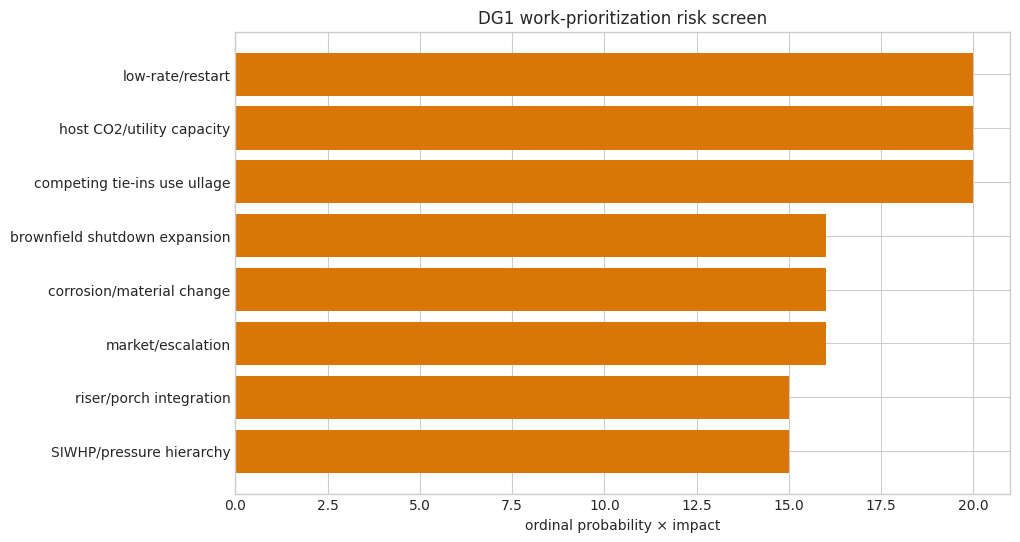

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))
top_risks = project_risks.head(8).sort_values("exposure")
ax.barh(
    top_risks["risk"],
    top_risks["exposure"],
    color="#d97706",
)
ax.set_xlabel("ordinal probability × impact")
ax.set_title("DG1 work-prioritization risk screen")
plt.show()


In [43]:
qualification_plan = pd.DataFrame(
    [
        (
            "HP wet-gas material",
            "application/environment",
            "weld/corrosion/installation",
            "qualified concept",
        ),
        (
            "long hydrate strategy",
            "operating envelope",
            "transient/MEG/restart",
            "verified philosophy",
        ),
        (
            "floating-host riser",
            "host integration",
            "motions/fatigue/loads",
            "feasible concept",
        ),
        (
            "high CO2 treatment",
            "capacity/brownfield scale",
            "rate model/utility/layout",
            "selected concept",
        ),
        (
            "90 km power/control",
            "distance/response",
            "load flow/dynamics/redundancy",
            "qualified architecture",
        ),
    ],
    columns=[
        "item",
        "novelty",
        "evidence needed",
        "target before DG2",
    ],
)
display(qualification_plan)


,item,novelty,evidence needed,target before DG2
0,HP wet-gas material,application/environment,weld/corrosion/installation,qualified concept
1,long hydrate strategy,operating envelope,transient/MEG/restart,verified philosophy
2,floating-host riser,host integration,motions/fatigue/loads,feasible concept
3,high CO2 treatment,capacity/brownfield scale,rate model/utility/layout,selected concept
4,90 km power/control,distance/response,load flow/dynamics/redundancy,qualified architecture


In [44]:
data_acquisition = pd.DataFrame(
    [
        ("fluid/PVT", "CCE/CVD, separator, water, H2S/CO2", "critical"),
        ("well", "test, PI, THP/THT, SIWHP, solids", "critical"),
        ("seabed", "bathymetry/geophysics/geotechnics", "critical"),
        ("metocean", "waves/currents/temperature", "high"),
        ("host process", "curves and life-of-field loads", "critical"),
        ("host structure", "3D scan/weight/porch/module", "critical"),
        ("utilities", "power/heat/cooling/flare/drains", "critical"),
        ("integrity", "materials/corrosion/inspection/life", "critical"),
        ("operations", "shutdown/maintenance/logistics", "high"),
        ("commercial", "tariff/allocation/capacity rights", "critical"),
    ],
    columns=["domain", "minimum next evidence", "priority"],
)
display(data_acquisition)


,domain,minimum next evidence,priority
0,fluid/PVT,"CCE/CVD, separator, water, H2S/CO2",critical
1,well,"test, PI, THP/THT, SIWHP, solids",critical
2,seabed,bathymetry/geophysics/geotechnics,critical
3,metocean,waves/currents/temperature,high
4,host process,curves and life-of-field loads,critical
5,host structure,3D scan/weight/porch/module,critical
6,utilities,power/heat/cooling/flare/drains,critical
7,integrity,materials/corrosion/inspection/life,critical
8,operations,shutdown/maintenance/logistics,high
9,commercial,tariff/allocation/capacity rights,critical


## 14. Probabilistic Class-4-style CAPEX screen

AACE estimate class reflects scope-definition maturity, not a guaranteed accuracy band.
Synthetic real-2026 MUSD values exclude wells, financing, and tax. Every WBS element uses a
triangular range and shared market factor:

$$C_{\mathrm{total}}=\sum_kC_k$$

A project estimate needs quantities, rates, escalation, currency, contracting, owner cost,
contingency method, exclusions, benchmarking, and estimate-basis review.


In [45]:
capex_basis = pd.DataFrame(
    [
        ("subsea template/manifold", "SURF", 280.0, 0.80, 1.35),
        ("flowline linepipe/coating", "SURF", 380.0, 0.80, 1.35),
        ("MEG/service line", "SURF", 110.0, 0.80, 1.35),
        ("umbilical/controls", "SURF", 145.0, 0.80, 1.35),
        ("riser/porch/tie-in", "SURF", 180.0, 0.75, 1.45),
        ("SURF installation", "SURF", 260.0, 0.75, 1.50),
        ("inlet/heating", "Facilities", 120.0, 0.75, 1.45),
        ("MDEA system", "Facilities", 300.0, 0.70, 1.55),
        ("compression/cooling", "Facilities", 210.0, 0.75, 1.45),
        ("TEG/MEG/liquids", "Facilities", 120.0, 0.75, 1.45),
        ("electrical/control/metering", "Facilities", 130.0, 0.75, 1.45),
        ("brownfield integration", "Facilities", 230.0, 0.65, 1.65),
        ("engineering/project", "Project", 300.0, 0.80, 1.40),
    ],
    columns=[
        "item",
        "area",
        "base_MUSD",
        "low_factor",
        "high_factor",
    ],
)
capex_basis["low_MUSD"] = (
    capex_basis["base_MUSD"] * capex_basis["low_factor"]
)
capex_basis["high_MUSD"] = (
    capex_basis["base_MUSD"] * capex_basis["high_factor"]
)
display(capex_basis)


,item,area,base_MUSD,low_factor,high_factor,low_MUSD,high_MUSD
0,subsea template/manifold,SURF,280.0,0.80,1.35,224.0,378.00
1,flowline linepipe/coating,SURF,380.0,0.80,1.35,304.0,513.00
2,MEG/service line,SURF,110.0,0.80,1.35,88.0,148.50
3,umbilical/controls,SURF,145.0,0.80,1.35,116.0,195.75
4,riser/porch/tie-in,SURF,180.0,0.75,1.45,135.0,261.00
5,SURF installation,SURF,260.0,0.75,1.50,195.0,390.00
6,inlet/heating,Facilities,120.0,0.75,1.45,90.0,174.00
7,MDEA system,Facilities,300.0,0.70,1.55,210.0,465.00
8,compression/cooling,Facilities,210.0,0.75,1.45,157.5,304.50
9,TEG/MEG/liquids,Facilities,120.0,0.75,1.45,90.0,174.00


In [46]:
simulation_count = 10000
shared_market_factor = RNG.lognormal(
    mean=-0.5 * 0.10**2,
    sigma=0.10,
    size=simulation_count,
)
cost_draws = {}
for row in capex_basis.itertuples():
    independent = RNG.triangular(
        row.low_MUSD,
        row.base_MUSD,
        row.high_MUSD,
        size=simulation_count,
    )
    cost_draws[row.item] = independent * shared_market_factor
capex_samples = pd.DataFrame(cost_draws)
capex_samples["total_MUSD"] = capex_samples.sum(axis=1)
capex_quantiles = capex_samples["total_MUSD"].quantile(
    [0.10, 0.50, 0.90]
)
capex_summary = pd.Series(
    {
        "deterministic base [MUSD]": capex_basis["base_MUSD"].sum(),
        "P10 [MUSD]": capex_quantiles.loc[0.10],
        "P50 [MUSD]": capex_quantiles.loc[0.50],
        "P90 [MUSD]": capex_quantiles.loc[0.90],
        "P90/P50": (
            capex_quantiles.loc[0.90] / capex_quantiles.loc[0.50]
        ),
    },
    name="probabilistic educational CAPEX",
)
display(capex_summary)


deterministic base [MUSD]    2765.000000
P10 [MUSD]                   2557.167442
P50 [MUSD]                   2935.521755
P90 [MUSD]                   3369.498166
P90/P50                         1.147836
Name: probabilistic educational CAPEX, dtype: float64

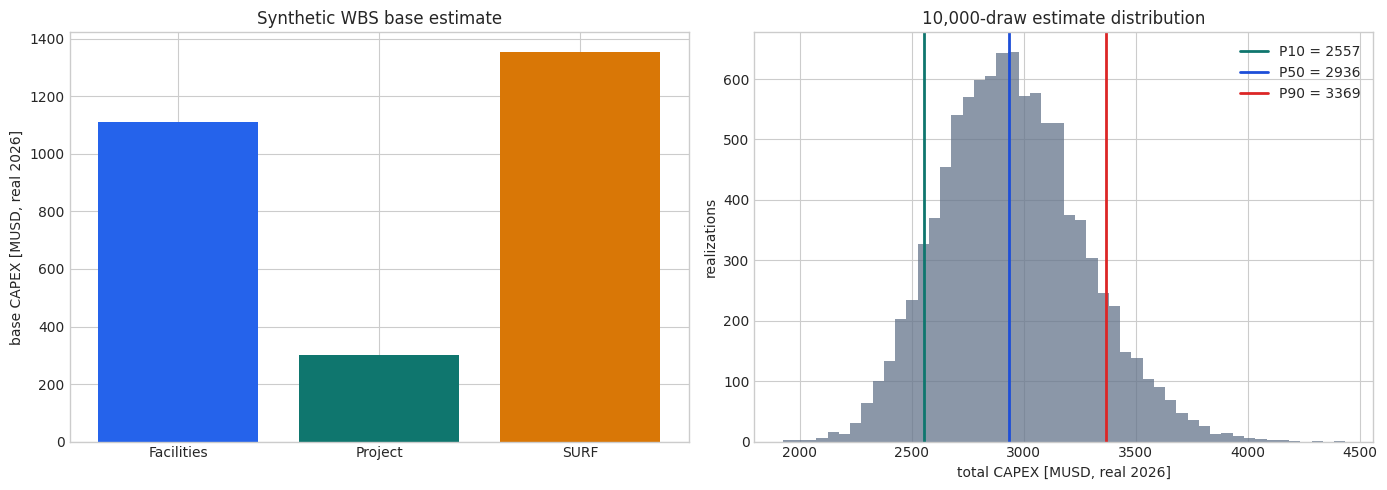

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
area_cost = capex_basis.groupby("area")["base_MUSD"].sum()
axes[0].bar(
    area_cost.index,
    area_cost.values,
    color=["#2563eb", "#0f766e", "#d97706"],
)
axes[0].set_ylabel("base CAPEX [MUSD, real 2026]")
axes[0].set_title("Synthetic WBS base estimate")
axes[1].hist(
    capex_samples["total_MUSD"],
    bins=50,
    color="#64748b",
    alpha=0.75,
)
for probability, color in [
    (0.10, "#0f766e"),
    (0.50, "#1d4ed8"),
    (0.90, "#dc2626"),
]:
    value = capex_quantiles.loc[probability]
    axes[1].axvline(
        value,
        color=color,
        linewidth=2,
        label=f"P{int(probability * 100)} = {value:.0f}",
    )
axes[1].set_xlabel("total CAPEX [MUSD, real 2026]")
axes[1].set_ylabel("realizations")
axes[1].set_title("10,000-draw estimate distribution")
axes[1].legend()
fig.tight_layout()
plt.show()


## 15. Integrated schedule

The schedule starts at a hypothetical DG1 authorization. Brownfield windows, long-lead
items, vessel markets, approval, partners, and host turnarounds must be integrated.


In [48]:
schedule = pd.DataFrame(
    [
        ("concept studies/select", 0, 8, "Engineering"),
        ("surveys/data acquisition", 0, 10, "Evidence"),
        ("host integration", 1, 12, "Brownfield"),
        ("technology qualification", 2, 16, "Assurance"),
        ("FEED/estimate maturation", 8, 12, "Engineering"),
        ("regulatory/partner path", 8, 16, "Governance"),
        ("detailed engineering", 20, 18, "Engineering"),
        ("long-lead procurement", 22, 22, "Supply"),
        ("host module fabrication", 24, 20, "Brownfield"),
        ("SURF fabrication", 24, 18, "Supply"),
        ("host modifications", 40, 9, "Offshore"),
        ("SURF installation", 42, 8, "Offshore"),
        ("commissioning/start-up", 49, 4, "Start-up"),
    ],
    columns=["activity", "start_month", "duration_month", "workstream"],
)
schedule["finish_month"] = (
    schedule["start_month"] + schedule["duration_month"]
)
display(schedule)


,activity,start_month,duration_month,workstream,finish_month
0,concept studies/select,0,8,Engineering,8
1,surveys/data acquisition,0,10,Evidence,10
2,host integration,1,12,Brownfield,13
3,technology qualification,2,16,Assurance,18
4,FEED/estimate maturation,8,12,Engineering,20
5,regulatory/partner path,8,16,Governance,24
6,detailed engineering,20,18,Engineering,38
7,long-lead procurement,22,22,Supply,44
8,host module fabrication,24,20,Brownfield,44
9,SURF fabrication,24,18,Supply,42


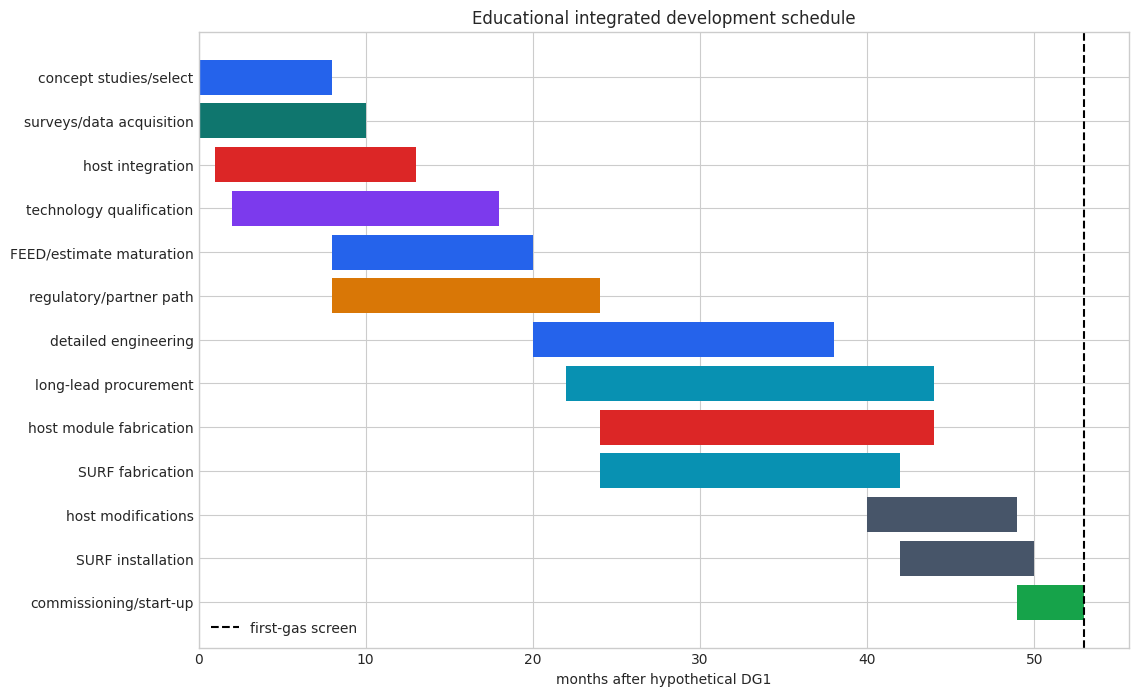

In [49]:
workstream_colors = {
    "Engineering": "#2563eb",
    "Evidence": "#0f766e",
    "Brownfield": "#dc2626",
    "Assurance": "#7c3aed",
    "Governance": "#d97706",
    "Supply": "#0891b2",
    "Offshore": "#475569",
    "Start-up": "#16a34a",
}
fig, ax = plt.subplots(figsize=(12, 8))
plot_schedule = schedule.iloc[::-1].reset_index(drop=True)
for index, row in plot_schedule.iterrows():
    ax.barh(
        index,
        row["duration_month"],
        left=row["start_month"],
        color=workstream_colors[row["workstream"]],
    )
ax.set_yticks(range(len(plot_schedule)))
ax.set_yticklabels(plot_schedule["activity"])
ax.set_xlabel("months after hypothetical DG1")
ax.set_title("Educational integrated development schedule")
ax.axvline(
    schedule["finish_month"].max(),
    color="black",
    linestyle="--",
    label="first-gas screen",
)
ax.legend()
plt.show()


## 16. Alternatives and transparent selection

- **A — 18-in HP wet-gas reference:** smallest candidate passing the stated rule; dedicated
  host treatment; no subsea compression.
- **B — 20-in shared-host treatment:** lower pressure loss but unverified host treatment,
  lower velocity, and more linepack.
- **C — 16-in compression-ready:** lower steel cost but the HIGH case becomes multiphase
  and future compression adds interfaces.

$$S=\sum_jw_jr_{ij}$$

Fatal flaws and mandatory requirements are never traded away by score.


In [50]:
criteria_weights = {
    "hydraulic_and_FA": 0.25,
    "host_integration": 0.20,
    "safety_and_integrity": 0.20,
    "capex": 0.15,
    "schedule": 0.10,
    "operability": 0.10,
}
concept_scores = pd.DataFrame(
    [
        ("A_18IN_DEDICATED", 4.0, 3.0, 3.5, 3.0, 3.0, 3.5, False),
        ("B_20IN_SHARED_HOST", 3.5, 2.0, 3.0, 4.0, 3.5, 2.5, False),
        ("C_16IN_COMPRESSION", 2.0, 3.0, 2.5, 3.5, 2.5, 2.5, True),
    ],
    columns=[
        "concept",
        "hydraulic_and_FA",
        "host_integration",
        "safety_and_integrity",
        "capex",
        "schedule",
        "operability",
        "fatal_flaw",
    ],
)
concept_scores["weighted_score"] = sum(
    concept_scores[criterion] * weight
    for criterion, weight in criteria_weights.items()
)
concept_scores["eligible"] = ~concept_scores["fatal_flaw"]
concept_scores = concept_scores.sort_values(
    ["eligible", "weighted_score"],
    ascending=[False, False],
)
display(concept_scores)


,concept,hydraulic_and_FA,host_integration,safety_and_integrity,capex,schedule,operability,fatal_flaw,weighted_score,eligible
0,A_18IN_DEDICATED,4.0,3.0,3.5,3.0,3.0,3.5,False,3.400,True
1,B_20IN_SHARED_HOST,3.5,2.0,3.0,4.0,3.5,2.5,False,3.075,True
2,C_16IN_COMPRESSION,2.0,3.0,2.5,3.5,2.5,2.5,True,2.625,False


Concept A remains the educational reference, conditional on treatment, utility, layout,
flare, and shutdown feasibility. Verified shared Åsgard capacity can reverse the ranking.
Concept C is held until a deliberate multiphase/transient or compression solution exists.


## 17. Educational DG1 deliverables matrix

“Notebook evidence” means this learning example contains an inspectable result.
“Real-project status” is stricter. This is not an official internal checklist.


In [51]:
deliverable_rows = [
    (
        "Governance",
        "DG1 decision memorandum",
        "decision/conditions/next budget",
        "section 19",
        "AMBER",
    ),
    (
        "Governance",
        "business opportunity/value case",
        "strategic/economic rationale",
        "predecessor",
        "AMBER",
    ),
    (
        "Governance",
        "project charter/scope",
        "objectives/boundaries/exclusions",
        "sections 1-2",
        "AMBER",
    ),
    ("Governance", "next-phase plan/budget", "work/owner/cost/schedule", "sections 13-15", "AMBER"),
    ("Governance", "partner/commercial strategy", "tariff/allocation/rights", "data plan", "RED"),
    ("Governance", "regulatory roadmap", "engagement/PDO/PIO/permits", "source map", "AMBER"),
    ("Subsurface", "P10/base/high profiles", "rate/pressure envelopes", "design cases", "AMBER"),
    ("Subsurface", "fluid/PVT/water basis", "composition/uncertainty", "section 3", "RED"),
    ("Wells", "well count/operating philosophy", "2+1/intervention", "handoff", "AMBER"),
    ("Wells", "THP/THT/SIWHP envelope", "normal/upset/shut-in", "interfaces", "RED"),
    ("SURF", "SURF design basis", "route/P/T/life", "sections 4-7", "AMBER"),
    ("SURF", "subsea architecture/list", "trees/manifold/controls", "subsea scope", "AMBER"),
    ("SURF", "route/survey plan", "bathymetry/hazards/geotech", "data plan", "RED"),
    ("SURF", "hydraulic diameter screen", "low/base/high", "pipeline screen", "AMBER"),
    ("SURF", "transient flow assurance", "start/stop/restart/slug", "FA register", "RED"),
    ("SURF", "hydrate/chemical management", "MEG/regeneration", "sections 6/9", "AMBER"),
    ("SURF", "mechanical/material basis", "wall/collapse/stability", "section 5", "RED"),
    ("SURF", "riser/host porch concept", "motion/fatigue/loads", "section 7", "RED"),
    ("SURF", "umbilical/power/control", "load/voltage/response", "section 7", "AMBER"),
    ("SURF", "installation/precommission", "vessels/test/dry", "cost/schedule", "AMBER"),
    ("SURF", "inspection/repair", "access/spares/vessel", "availability", "AMBER"),
    ("Facilities", "battery limits", "stream/responsibility", "interfaces", "AMBER"),
    ("Facilities", "block flow/process description", "functions/products", "section 2", "AMBER"),
    ("Facilities", "heat/material balance", "low/base/high NeqSim", "process results", "AMBER"),
    ("Facilities", "PFD/stream data", "named path/conditions", "sections 2/8", "AMBER"),
    ("Facilities", "equipment list/sizing", "separator/heat/compression", "section 9", "AMBER"),
    ("Facilities", "utility/load summary", "power/heat/cooling", "section 10", "AMBER"),
    ("Facilities", "host capacity/ullage", "life-of-field margins", "brownfield", "RED"),
    ("Facilities", "brownfield tie-in register", "system/shutdown", "section 11", "AMBER"),
    ("Facilities", "weight/plot-space", "weight/area/access", "section 11", "AMBER"),
    ("Facilities", "metering/allocation/export", "quality/fiscal interfaces", "tie-ins", "RED"),
    ("Facilities", "control/safeguarding", "PSD/ESD/F&G/surge", "section 12", "RED"),
    ("Facilities", "relief/flare/depressuring", "loads/network/wall T", "section 12", "RED"),
    ("Facilities", "operability/maintenance", "turndown/access/spares", "sections 6/7", "AMBER"),
    ("HSE", "HSE programme/criteria", "studies/reviews/owners", "risk map", "RED"),
    ("HSE", "HAZID/action register", "hazards/safeguards", "sections 12-13", "AMBER"),
    ("HSE", "barrier/major accident", "functions/performance", "safeguards", "RED"),
    ("HSE", "ALARP plan", "options/further reduction", "risk responses", "RED"),
    ("Environment", "energy/emissions", "power/heat/CO2/BAT", "section 10", "AMBER"),
    ("Environment", "discharge/chemical/seabed", "MEG/amine/water/route", "data plan", "RED"),
    ("Project", "technology qualification", "novelty/evidence/target", "section 13", "AMBER"),
    ("Project", "data acquisition", "critical discipline evidence", "section 13", "AMBER"),
    ("Project", "CAPEX/uncertainty", "WBS/class/range", "section 14", "AMBER"),
    ("Project", "OPEX/lifecycle resources", "chemical/energy/logistics", "utilities/RAM", "RED"),
    ("Project", "schedule/critical path", "gate-to-first-gas", "section 15", "AMBER"),
    ("Project", "execution/contracting", "packages/market/interfaces", "schedule/cost", "RED"),
    ("Project", "quality/assurance", "reviews/independence", "section 18", "AMBER"),
    ("Project", "opportunity/risk register", "exposure/response/closure", "section 13", "AMBER"),
    ("Project", "alternatives/screening", "options/weights/flaws", "section 16", "AMBER"),
    ("Project", "DG1 conditions/next work", "critical closures", "section 19", "AMBER"),
]
deliverables = pd.DataFrame(
    deliverable_rows,
    columns=[
        "area",
        "deliverable",
        "DG1 learning acceptance",
        "notebook evidence",
        "real-project status",
    ],
)
deliverables["official_internal_checklist"] = False
display(deliverables)
print("Educational DG1 deliverables:", len(deliverables))


Educational DG1 deliverables: 50


,area,deliverable,DG1 learning acceptance,notebook evidence,real-project status,official_internal_checklist
0,Governance,DG1 decision memorandum,decision/conditions/next budget,section 19,AMBER,False
1,Governance,business opportunity/value case,strategic/economic rationale,predecessor,AMBER,False
2,Governance,project charter/scope,objectives/boundaries/exclusions,sections 1-2,AMBER,False
3,Governance,next-phase plan/budget,work/owner/cost/schedule,sections 13-15,AMBER,False
4,Governance,partner/commercial strategy,tariff/allocation/rights,data plan,RED,False
5,Governance,regulatory roadmap,engagement/PDO/PIO/permits,source map,AMBER,False
6,Subsurface,P10/base/high profiles,rate/pressure envelopes,design cases,AMBER,False
7,Subsurface,fluid/PVT/water basis,composition/uncertainty,section 3,RED,False
8,Wells,well count/operating philosophy,2+1/intervention,handoff,AMBER,False
9,Wells,THP/THT/SIWHP envelope,normal/upset/shut-in,interfaces,RED,False


real-project status,RED,AMBER,GREEN
area,,,
Environment,1,1,0
Facilities,4,9,0
Governance,1,5,0
HSE,3,1,0
Project,2,8,0
SURF,4,7,0
Subsurface,1,1,0
Wells,1,1,0


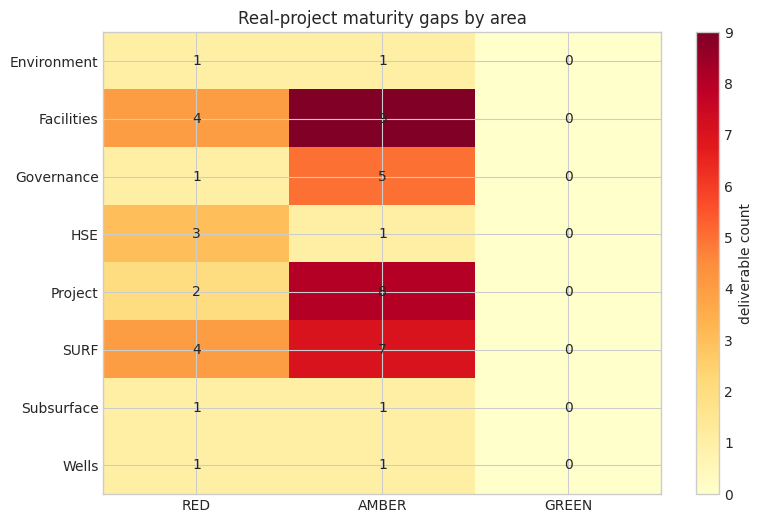

In [52]:
maturity = (
    deliverables.groupby(["area", "real-project status"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["RED", "AMBER", "GREEN"], fill_value=0)
)
display(maturity)
fig, ax = plt.subplots(figsize=(9, 6))
image_data = maturity.to_numpy()
image = ax.imshow(image_data, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(maturity.columns)))
ax.set_xticklabels(maturity.columns)
ax.set_yticks(range(len(maturity.index)))
ax.set_yticklabels(maturity.index)
for row_index in range(image_data.shape[0]):
    for column_index in range(image_data.shape[1]):
        ax.text(
            column_index,
            row_index,
            int(image_data[row_index, column_index]),
            ha="center",
            va="center",
        )
ax.set_title("Real-project maturity gaps by area")
fig.colorbar(image, ax=ax, label="deliverable count")
plt.show()


## 18. Machine-checkable educational gates

Passing calculations prove internal consistency, not closure of RED project items. The
evidence ladder is benchmark, independent calculation, conservation, then physical bounds.
This notebook reaches levels 2–4 for selected screens, not asset validation.


In [53]:
selected_check = diameter_decision.query(
    "nominal_OD_in == @SELECTED_OD_IN"
).iloc[0]
acceptance_gates = {
    "composition normalized": abs(
        sum(LINNORM_COMPOSITION.values()) - 1.0
    )
    < 1.0e-12,
    "predecessor commit recorded": len(
        PREDECESSOR_HANDOFF["repository_commit"]
    )
    == 40,
    "validated NeqSim used": runtime["neqsim"] == NEQSIM_VERSION,
    "line passes hydraulic rule": bool(
        selected_check["DG1_screen_passed"]
    ),
    "steady cases single phase": bool(
        (selected_pipeline["phases"] == 1).all()
    ),
    "wall exceeds requirement": (
        SELECTED_WALL_MM >= required_nominal_m * 1000.0
    ),
    "stability screen passes": bool(
        stability_screen.loc[
            stability_screen["concrete_coating_mm"]
            == SELECTED_COATING_MM,
            "stability_ratio",
        ].iloc[0]
        >= 1.0
    ),
    "20 wt% MEG below seabed": (
        meg20_hydrate_C
        < DESIGN_BASIS["seabed_temperature_C"]
    ),
    "process outputs finite": bool(
        np.isfinite(
            process_results.select_dtypes(include=[float, int])
        ).all().all()
    ),
    "process closures small": bool(
        (process_results["mass_closure_kg_h"].abs() < 1.0e-6).all()
    ),
    "treated CO2 below one mol%": bool(
        (process_results["treated_CO2_molpct"] < 1.0).all()
    ),
    "CAPEX quantiles ordered": bool(
        capex_quantiles.loc[0.10]
        < capex_quantiles.loc[0.50]
        < capex_quantiles.loc[0.90]
    ),
    "schedule reaches commissioning": bool(
        schedule["finish_month"].max() >= 50
    ),
    "at least 45 deliverables": len(deliverables) >= 45,
    "all source URLs HTTPS": bool(
        sources["url"].str.startswith("https://").all()
    ),
}
acceptance_table = pd.DataFrame(
    [
        {"gate": gate, "passed": bool(passed)}
        for gate, passed in acceptance_gates.items()
    ]
)
display(acceptance_table)
assert acceptance_table["passed"].all()
print("ALL EDUCATIONAL CALCULATION GATES PASSED")


ALL EDUCATIONAL CALCULATION GATES PASSED


,gate,passed
0,composition normalized,True
1,predecessor commit recorded,True
2,validated NeqSim used,True
3,line passes hydraulic rule,True
4,steady cases single phase,True
5,wall exceeds requirement,True
6,stability screen passes,True
7,20 wt% MEG below seabed,True
8,process outputs finite,True
9,process closures small,True


## 19. Conditional DG1 learning recommendation

**Advance concept A—an 18-inch nominal HP wet-gas tie-back with MEG, floating-host
riser/tie-in, and dedicated incremental treatment—into formal concept studies. Do not claim
a real DG1 pass.**

The 18-inch candidate is the smallest diameter passing the stated low/base/high rule.
NeqSim shows that pressure letdown, heating, separation, CO₂ removal, compression, cooling,
and liquid systems are coupled. MDEA regeneration, utilities, module weight, and tie-ins
mean “direct” remains conditional.

Real DG1 hold points:

1. approved PVT/water/H₂S and well/SIWHP envelopes;
2. terrain and transient startup/shutdown/restart model;
3. host capacity, utilities, flare, layout, structure, integrity, shutdowns, and competing
   tie-ins;
4. material, corrosion, riser, F101/F109/free-span/installation concept;
5. HAZID, risk criteria, barriers, pressure protection/HIPPS, environment, and emergency
   response;
6. market-tested cost/schedule, commercial access, partners, and regulatory plan.

Verified shared Åsgard treatment can reverse the ranking. Infeasible host integration
returns Kristin and other area solutions to the decision set.


## 20. Export the auditable educational package

Key results remain visible here; the ZIP is a reusable handoff, not the only evidence.


In [54]:
package_directory = RUN_DIRECTORY / "linnorm_dg1_package"
package_directory.mkdir(exist_ok=True)
export_tables = {
    "sources.csv": sources,
    "design_cases.csv": design_cases,
    "composition.csv": composition_table,
    "flash_summary.csv": flash_summary,
    "pipeline_screen.csv": pipeline_screen,
    "diameter_decision.csv": diameter_decision,
    "stability_screen.csv": stability_screen,
    "hydrate_screen.csv": hydrate_screen,
    "thermal_summary.csv": thermal_summary,
    "flow_assurance.csv": flow_assurance_register,
    "subsea_scope.csv": subsea_scope,
    "umbilical_screen.csv": umbilical_screen,
    "availability.csv": availability_basis,
    "process_results.csv": process_results,
    "process_profile.csv": process_profile,
    "equipment_size.csv": equipment_size,
    "liquid_systems.csv": liquid_systems,
    "utility_loads.csv": utility_loads,
    "energy_options.csv": energy_options,
    "brownfield_tie_ins.csv": brownfield_tie_ins,
    "module_items.csv": module_items,
    "safeguards.csv": safeguards,
    "project_risks.csv": project_risks,
    "qualification_plan.csv": qualification_plan,
    "data_acquisition.csv": data_acquisition,
    "capex_basis.csv": capex_basis,
    "schedule.csv": schedule,
    "concept_scores.csv": concept_scores,
    "deliverables.csv": deliverables,
    "acceptance_gates.csv": acceptance_table,
}
for filename, table in export_tables.items():
    table.to_csv(package_directory / filename, index=False)
package_basis = {
    "predecessor_handoff": PREDECESSOR_HANDOFF,
    "handoff_sha256": HANDOFF_SHA256,
    "design_basis": DESIGN_BASIS,
    "runtime": runtime,
    "selected_OD_in": SELECTED_OD_IN,
    "selected_wall_mm": SELECTED_WALL_MM,
    "selected_coating_mm": SELECTED_COATING_MM,
    "capex_P10_P50_P90_MUSD": [
        float(capex_quantiles.loc[0.10]),
        float(capex_quantiles.loc[0.50]),
        float(capex_quantiles.loc[0.90]),
    ],
    "official_internal_checklist": False,
    "educational_only": True,
}
(package_directory / "design_basis.json").write_text(
    json.dumps(package_basis, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
summary_text = f'''# Linnorm educational DG1 summary

- Reference: A, dedicated host treatment
- Flowline: {SELECTED_OD_IN:.0f}-in OD
- Wall: {SELECTED_WALL_MM:.1f} mm
- Coating: {SELECTED_COATING_MM:.0f} mm
- CAPEX P10/P50/P90: {capex_quantiles.loc[0.10]:.0f}/
  {capex_quantiles.loc[0.50]:.0f}/{capex_quantiles.loc[0.90]:.0f} MUSD
- First gas: {schedule["finish_month"].max():.0f} months after DG1
- Real-project gate: NOT DEMONSTRATED

Synthetic educational package; not an official DG1 package.
'''
(package_directory / "summary.md").write_text(
    textwrap.dedent(summary_text).strip() + "\n",
    encoding="utf-8",
)
manifest_rows = []
for path in sorted(package_directory.iterdir()):
    if path.name == "manifest.csv":
        continue
    payload = path.read_bytes()
    manifest_rows.append(
        {
            "path": path.name,
            "bytes": len(payload),
            "sha256": hashlib.sha256(payload).hexdigest(),
        }
    )
manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(package_directory / "manifest.csv", index=False)
zip_path = RUN_DIRECTORY / "linnorm_dg1_package.zip"
with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for path in sorted(package_directory.iterdir()):
        archive.write(path, arcname=path.name)
PACKAGE_SHA256 = hashlib.sha256(zip_path.read_bytes()).hexdigest()
print("Package:", zip_path)
print("Package SHA-256:", PACKAGE_SHA256)
display(manifest)


Package: /tmp/linnorm-drawing-run-9S3P2k/linnorm_dg1_run/linnorm_dg1_package.zip
Package SHA-256: a28ebab0fce808a79b21ea11554c9385abbf0adf19fdd14aa484c90b9c00d04e


,path,bytes,sha256
0,acceptance_gates.csv,461,7608730ba5cdab21bd600747866c10624460cf8c97caf8...
1,availability.csv,213,9723374327771f9c25a4dec5462279e1ab3c5f347439ad...
2,brownfield_tie_ins.csv,823,24732a732502f0bec9c8cafc5c2a3156b0a006e34d606b...
3,capex_basis.csv,776,6425073497a87a37bf6d96e8867b3734d330ee4cc194a6...
4,composition.csv,305,a25a18db65346c0d8851dfd98b8a1794e277ee5f8c5edc...
5,concept_scores.csv,301,d81860a99c8ea583daf6c928049639748557566ebd9ef0...
6,data_acquisition.csv,546,2ccb87a1afd94cb0c1b23674968b6195558903671c312d...
7,deliverables.csv,3932,e8cd90524bbb89d6e6d367d12bc4687847c02a817ae8c9...
8,design_basis.json,1740,cd943b4a933f6375782b47bb3568d00ebf10d61726d638...
9,design_cases.csv,194,898ba3ea523f40ef59283213c477af6d769071730016ce...


In [55]:
final_gates = acceptance_gates.copy()
final_gates["package exists"] = zip_path.exists()
final_gates["package hash is SHA-256"] = len(PACKAGE_SHA256) == 64
final_gate_table = pd.DataFrame(
    [
        {"gate": gate, "passed": bool(passed)}
        for gate, passed in final_gates.items()
    ]
)
assert final_gate_table["passed"].all()
display(final_gate_table)
print("FINAL PACKAGE AND CALCULATION GATES PASSED")


FINAL PACKAGE AND CALCULATION GATES PASSED


,gate,passed
0,composition normalized,True
1,predecessor commit recorded,True
2,validated NeqSim used,True
3,line passes hydraulic rule,True
4,steady cases single phase,True
5,wall exceeds requirement,True
6,stability screen passes,True
7,20 wt% MEG below seabed,True
8,process outputs finite,True
9,process closures small,True


## Learning review

1. A reservoir-to-host screen is a DG1 input, not its conclusion.
2. Diameter couples hydraulics, phases, low-flow transport, mechanics, installation,
   linepack, and future compression.
3. High arrival pressure can create pressure-letdown and hydrate problems despite small
   pipeline pressure drop.
4. CO₂ removal can dominate heat, plot, weight, utility, emissions, and integration.
5. A direct tie-back can require extensive brownfield modules and shutdown work.
6. Passing assertions does not close RED data gaps.
7. A useful DG1 package states what to verify, who owns it, why it matters, and what
   decision it can reverse.


## Suggested exercises

1. Reproduce wall thickness and list omitted DNV checks.
2. Change receiving pressure from 95 to 70 bara and explain JT cooling, heat, compression,
   and safeguarding.
3. Remove MEG and calculate low-rate hydrate exposure.
4. Trace one predecessor number through pipeline, process, utility, cost, and gate tables.
5. Add a terrain profile and transient two-fluid model.
6. Compare one 18-inch line, dual lines, and a piggable loop.
7. Add rate-based MDEA/TEG with complete solvent mass and energy closure.
8. Add compressor maps, surge, stonewall, recycle, staging, and driver constraints.
9. Build transient blowdown with wall temperature and flare peak.
10. Add riser fatigue, spans, buckling, and installation limit states.
11. Give every RED deliverable an owner, date, cost, and acceptance evidence.
12. Re-rank host options with verified Åsgard and Kristin capacity.


## References and reproducibility

- [Predecessor Linnorm Colab](../reservoir/linnorm_ncs_tie_in_opm_neqsim_master.ipynb)
- [Equinor Capital Value Process](https://www.equinor.com/about-us/corporate-governance)
- [Equinor Linnorm announcement](https://www.equinor.com/news/20231214-increasing-ownership-linnorm-discovery)
- [Equinor Åsgard](https://www.equinor.com/energy/asgard)
- [SODIR PDO/PIO guidance](https://www.sodir.no/globalassets/1-sodir/regelverk/forskrifter/en/pdo-and-pio.pdf)
- [Havtil risk reduction](https://www.havtil.no/en/regulations/all-acts/the-framework-regulations3/II/11/)
- [Havtil risk analyses](https://www.havtil.no/en/regulations/all-acts/the-management-regulations3/V/17/)
- [NORSOK P category](https://standard.no/en/sectors/petroleum/norsok-standards/p-process)
- [NORSOK U category](https://standard.no/en/sectors/petroleum/norsok-standards/u-subsea)
- [DNV pipeline codes](https://www.dnv.com/energy/services/pipelines/pipeline-codes/)
- [DNV-RP-F109](https://www.dnv.com/energy/standards-guidelines/dnv-rp-f109-on-bottom-stability-design-of-submarine-pipelines/)
- [AACE 18R-97](https://web.aacei.org/docs/default-source/toc/toc_18r-97.pdf)
- [NeqSim](https://github.com/equinor/neqsim)

Saved outputs use NeqSim Python 3.16.0. Re-execution records the actual runtime and hashes.
Reproducibility makes assumptions auditable; it does not make analogues field validated.
